In [21]:
# ── Data access ───────────────────────────────────────────────
import eurostat                          # Eurostat API
import pandas as pd                      # Data manipulation
import numpy as np                       # Numerical operations

# ── Regression ────────────────────────────────────────────────
from linearmodels.panel import PanelOLS  # Two-way FE estimator

# ── Excel export (backend for pd.ExcelWriter) ─────────────────
import openpyxl                          # Required by pandas for .xlsx writes

In [22]:
# ============================================================
# STEP 2 — INDEPENDENT VARIABLES (RRF financial flows)
# Source: Eurostat gov_rrf_fa
# ============================================================

df_rrf_raw = eurostat.get_data_df('gov_rrf_fa')
df_rrf_raw = df_rrf_raw.rename(columns={'geo\\TIME_PERIOD': 'country'})

year_cols = ['2020', '2021', '2022', '2023', '2024']

# ---- Variable definitions ----
# Each tuple: (label, fin_typ, na_item, finpos, stk_flow)
variable_specs = {
    'grants_main': ('GRNT', 'F2R_F4R',    'NET', 'STK'),
    'loans_main':  ('LOAN', 'F2R_F4R',    'NET', 'STK'),
    'grants_rob1': ('GRNT', 'F89',         'ASS', 'STK'),
    'grants_rob2': ('GRNT', 'F2R_F4R_AP', 'NET', 'STK'),
    'loans_rob':   ('LOAN', 'F2',          'NET', 'STK'),
    'total':       ('TOTAL','F2R_F4R',    'NET', 'STK'),
}

# ---- Extract, reshape, and combine ----
dfs = []

for label, (fin_typ, na_item, finpos, stk_flow) in variable_specs.items():
    subset = df_rrf_raw[
        (df_rrf_raw['fin_typ']  == fin_typ)  &
        (df_rrf_raw['na_item']  == na_item)  &
        (df_rrf_raw['finpos']   == finpos)   &
        (df_rrf_raw['stk_flow'] == stk_flow) &
        (df_rrf_raw['unit'].isin(['PC_GDP', 'MIO_EUR', 'PC_ALLOC']))
    ].copy()

    long = subset.melt(
        id_vars=['country', 'fin_typ', 'na_item', 'finpos', 'stk_flow', 'unit'],
        value_vars=year_cols,
        var_name='year',
        value_name='value'
    )
    long['year']   = long['year'].astype(int)
    long['source'] = label
    dfs.append(long)

df_rrf_long = pd.concat(dfs, ignore_index=True)

# ---- Diagnostics ----
eu27 = [
    'AT','BE','BG','CY','CZ','DE','DK','EE','EL','ES',
    'FI','FR','HR','HU','IE','IT','LT','LU','LV','MT',
    'NL','PL','PT','RO','SE','SI','SK'
]

print("=== STEP 2: RRF VARIABLES — DIAGNOSTIC REPORT ===\n")
print(f"Total rows (all countries, all variables): {len(df_rrf_long)}")
print(f"EU27-only rows: {len(df_rrf_long[df_rrf_long['country'].isin(eu27)])}\n")

for label in variable_specs:
    sub = df_rrf_long[
        (df_rrf_long['source']  == label) &
        (df_rrf_long['country'].isin(eu27)) &
        (df_rrf_long['unit']    == 'MIO_EUR')
    ]
    countries = sorted(sub['country'].unique())
    missing   = sub['value'].isna().sum()
    print(f"  {label:15s} | {len(countries):2d} countries | {missing:3d} NaN values")
    if label in ('loans_main', 'loans_rob'):
        non_eu27 = sorted(set(eu27) - set(countries))
        print(f"  {'':15s}   Countries present:     {countries}")
        print(f"  {'':15s}   Non-requesting (NaN):  {non_eu27}")
    print()

=== STEP 2: RRF VARIABLES — DIAGNOSTIC REPORT ===

Total rows (all countries, all variables): 2050
EU27-only rows: 1960

  grants_main     | 27 countries |  26 NaN values

  loans_main      | 13 countries |  17 NaN values
                    Countries present:     ['BE', 'CY', 'CZ', 'EL', 'ES', 'HR', 'HU', 'IT', 'LT', 'PL', 'PT', 'RO', 'SI']
                    Non-requesting (NaN):  ['AT', 'BG', 'DE', 'DK', 'EE', 'FI', 'FR', 'IE', 'LU', 'LV', 'MT', 'NL', 'SE', 'SK']

  grants_rob1     | 27 countries |  13 NaN values

  grants_rob2     | 27 countries |  30 NaN values

  loans_rob       | 10 countries |  17 NaN values
                    Countries present:     ['BE', 'EL', 'ES', 'HR', 'IT', 'LT', 'PL', 'PT', 'RO', 'SI']
                    Non-requesting (NaN):  ['AT', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'FI', 'FR', 'HU', 'IE', 'LU', 'LV', 'MT', 'NL', 'SE', 'SK']

  total           | 27 countries |   0 NaN values



In [23]:
# ============================================================
# STEP 3 — DEPENDENT VARIABLE AND MODERATOR
# ============================================================

# ---- 3A: nrg_inf_epcrw — Renewable electricity installed capacity ----
# plant_tec = CAP_NET_ELC  → harmonised net capacity
# unit      = MW           → only option available, no filter needed
# siec      = top-level codes only — children excluded by design:
#             RA100 hydro, RA200 geothermal, RA300 wind,
#             RA400 solar, R5100 solid biofuels, R5300 biogases

df_epcrw_raw = eurostat.get_data_df('nrg_inf_epcrw')
df_epcrw_raw = df_epcrw_raw.rename(columns={'geo\\TIME_PERIOD': 'country'})

siec_codes = {
    'RA100': 'hydro',
    'RA200': 'geothermal',
    'RA300': 'wind',
    'RA400': 'solar',
    'R5100': 'solid_biofuels',
    'R5300': 'biogases',
}

year_cols = [str(y) for y in range(2018, 2025)]

df_cap = df_epcrw_raw[
    (df_epcrw_raw['plant_tec'] == 'CAP_NET_ELC') &
    (df_epcrw_raw['siec'].isin(siec_codes.keys()))
].copy()

df_cap['re_type'] = df_cap['siec'].map(siec_codes)

df_cap_long = df_cap.melt(
    id_vars=['country', 'siec', 're_type', 'plant_tec', 'unit'],
    value_vars=year_cols,
    var_name='year',
    value_name='cap_mw'
)
df_cap_long['year'] = df_cap_long['year'].astype(int)
df_cap_long = df_cap_long.sort_values(
    ['country', 'siec', 'year']
).reset_index(drop=True)

# ---- Data corrections (confirmed reporting/reclassification errors) ----
# Croatia 2024 hydro: raw value = 0 MW, prior year = 2,189.9 MW
# Six stable years (~2,200 MW) then exact zero → clear reporting error
# Treatment: carry forward 2023 value
mask_hr_hydro = (
    (df_cap_long['country'] == 'HR') &
    (df_cap_long['siec']    == 'RA100') &
    (df_cap_long['year']    == 2024)
)
df_cap_long.loc[mask_hr_hydro, 'cap_mw'] = 2189.9

# Estonia 2024 solid biofuels: raw value = 974 MW, prior year = 200 MW
# Six consecutive flat years at 200 MW then 5× jump → reclassification artefact
# Treatment: carry forward 2023 value
mask_ee_biofuels = (
    (df_cap_long['country'] == 'EE') &
    (df_cap_long['siec']    == 'R5100') &
    (df_cap_long['year']    == 2024)
)
df_cap_long.loc[mask_ee_biofuels, 'cap_mw'] = 200.0

# Estonia 2024 wind: raw value = 693 MW, prior year = 340 MW
# Flat series 2019-2023 (316-340 MW) then 2× jump in one year
# → reclassification artefact, consistent with handover flag
# Treatment: carry forward 2023 value
mask_ee_wind = (
    (df_cap_long['country'] == 'EE') &
    (df_cap_long['siec']    == 'RA300') &
    (df_cap_long['year']    == 2024)
)
df_cap_long.loc[mask_ee_wind, 'cap_mw'] = 340.0

# ---- Diagnostics 3A ----
eu27 = [
    'AT','BE','BG','CY','CZ','DE','DK','EE','EL','ES',
    'FI','FR','HR','HU','IE','IT','LT','LU','LV','MT',
    'NL','PL','PT','RO','SE','SI','SK'
]

df_cap_eu27 = df_cap_long[df_cap_long['country'].isin(eu27)]

print("=== 3A: RENEWABLE CAPACITY ===")
print(f"Total rows (EU27): {len(df_cap_eu27)}")
print(f"Expected:          {27 * 7 * 6} (27 countries × 7 years × 6 technologies)")
print(f"Missing values:    {df_cap_eu27['cap_mw'].isna().sum()}")
print(f"\nSIEC codes present: {sorted(df_cap_eu27['siec'].unique())}")
print(f"Years present:      {sorted(df_cap_eu27['year'].unique())}")
print()

print("Corrections applied — verify values:")
print(f"  HR 2024 hydro:          {df_cap_long[mask_hr_hydro]['cap_mw'].values[0]} MW (was 0)")
print(f"  EE 2024 solid biofuels: {df_cap_long[mask_ee_biofuels]['cap_mw'].values[0]} MW (was 974)")
print(f"  EE 2024 wind:           {df_cap_long[mask_ee_wind]['cap_mw'].values[0]} MW (was 693)")


# ---- 3B: nrg_inf_epc — Total and fossil electricity capacity ----
# siec     = TOTAL (denominator) and CF (fossil numerator for fossil_share)
# plant_tec = CAP_NET_ELC
# operator  = TOTAL where available, else PRR_MAIN + PRR_AUTO
# Aggregates (EA20, EA21, EU27_2020) excluded

df_epc_raw = eurostat.get_data_df('nrg_inf_epc')
df_epc_raw = df_epc_raw.rename(columns={'geo\\TIME_PERIOD': 'country'})

aggregates = ['EA20', 'EA21', 'EU27_2020']

df_epc_sub = df_epc_raw[
    (df_epc_raw['plant_tec'] == 'CAP_NET_ELC') &
    (df_epc_raw['siec'].isin(['TOTAL', 'CF'])) &
    (~df_epc_raw['country'].isin(aggregates))
].copy()

# For each country/siec/year: use TOTAL operator if available,
# else sum PRR_MAIN + PRR_AUTO
df_epc_pivot = df_epc_sub.pivot_table(
    index=['country', 'siec'],
    columns='operator',
    values=year_cols,
    aggfunc='first'
)
df_epc_pivot.columns = [f'{yr}_{op}' for yr, op in df_epc_pivot.columns]
df_epc_pivot = df_epc_pivot.reset_index()

records = []
for _, row in df_epc_pivot.iterrows():
    country = row['country']
    siec    = row['siec']
    for yr in year_cols:
        total_val = row.get(f'{yr}_TOTAL', None)
        main_val  = row.get(f'{yr}_PRR_MAIN', None)
        auto_val  = row.get(f'{yr}_PRR_AUTO', None)

        if pd.notna(total_val):
            value  = total_val
            source = 'TOTAL'
        elif pd.notna(main_val) or pd.notna(auto_val):
            value  = (main_val or 0) + (auto_val or 0)
            source = 'PRR_MAIN+PRR_AUTO'
        else:
            value  = None
            source = 'missing'

        records.append({
            'country':         country,
            'siec':            siec,
            'year':            int(yr),
            'cap_mw':          value,
            'operator_source': source
        })

df_epc_long = pd.DataFrame(records)

# ---- Diagnostics 3B ----
df_epc_eu27 = df_epc_long[df_epc_long['country'].isin(eu27)]

print("=== 3B: TOTAL AND FOSSIL CAPACITY ===")
print(f"Total rows (EU27): {len(df_epc_eu27)}")
print(f"Expected:          {27 * 7 * 2} (27 countries × 7 years × 2 siec codes)")
print()

for siec_code in ['TOTAL', 'CF']:
    sub = df_epc_eu27[df_epc_eu27['siec'] == siec_code]
    missing = sub['cap_mw'].isna().sum()
    prr = (sub['operator_source'] == 'PRR_MAIN+PRR_AUTO').sum()
    print(f"  {siec_code}: {missing} missing | {prr} rows from PRR_MAIN+PRR_AUTO")

print()
print("Operator source breakdown:")
print(df_epc_eu27['operator_source'].value_counts().to_string())


# ---- 3C: nrg_ind_ren — RE share and baseline moderator ----
# nrg_bal = REN     → total RE share (main moderator source + robustness DV)
# nrg_bal = REN_ELC → electricity-only RE share (robustness DV)
# Excluded: REN_TRA, REN_HEAT_CL, REN_HEAT_CL_WHC, REN_WHC_DHEAT_DCL

df_ren_raw = eurostat.get_data_df('nrg_ind_ren')
df_ren_raw = df_ren_raw.rename(columns={'geo\\TIME_PERIOD': 'country'})

nrg_bal_codes = {
    'REN':     're_share_total',
    'REN_ELC': 're_share_elc',
}

df_ren_sub = df_ren_raw[
    df_ren_raw['nrg_bal'].isin(nrg_bal_codes.keys())
].copy()
df_ren_sub['re_share_type'] = df_ren_sub['nrg_bal'].map(nrg_bal_codes)

df_ren_long = df_ren_sub.melt(
    id_vars=['country', 'nrg_bal', 're_share_type', 'unit'],
    value_vars=year_cols,
    var_name='year',
    value_name='re_share_pct'
)
df_ren_long['year'] = df_ren_long['year'].astype(int)
df_ren_long = df_ren_long.sort_values(
    ['country', 'nrg_bal', 'year']
).reset_index(drop=True)

# ---- Baseline moderating variable: 2019-2020 average REN share ----
df_baseline = (
    df_ren_long[
        (df_ren_long['nrg_bal'] == 'REN') &
        (df_ren_long['year'].isin([2019, 2020]))
    ]
    .groupby('country')['re_share_pct']
    .mean()
    .reset_index()
    .rename(columns={'re_share_pct': 'baseline_re_share'})
)

# ---- Diagnostics 3C ----
df_ren_eu27 = df_ren_long[df_ren_long['country'].isin(eu27)]
df_baseline_eu27 = df_baseline[df_baseline['country'].isin(eu27)]

print("\n=== 3C: RE SHARE AND BASELINE ===")
print(f"RE share rows (EU27): {len(df_ren_eu27)}")
print(f"Expected:             {27 * 7 * 2} (27 countries × 7 years × 2 indicators)")
print(f"Missing values:       {df_ren_eu27['re_share_pct'].isna().sum()}")
print()
print(f"Baseline countries:   {len(df_baseline_eu27)} (expected 27)")
print(f"Missing baseline:     {df_baseline_eu27['baseline_re_share'].isna().sum()}")
print()
print("Baseline RE share by country (2019-2020 avg):")
print(
    df_baseline_eu27
    .sort_values('baseline_re_share', ascending=False)
    .to_string(index=False)
)

=== 3A: RENEWABLE CAPACITY ===
Total rows (EU27): 1134
Expected:          1134 (27 countries × 7 years × 6 technologies)
Missing values:    0

SIEC codes present: ['R5100', 'R5300', 'RA100', 'RA200', 'RA300', 'RA400']
Years present:      [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Corrections applied — verify values:
  HR 2024 hydro:          2189.9 MW (was 0)
  EE 2024 solid biofuels: 200.0 MW (was 974)
  EE 2024 wind:           340.0 MW (was 693)
=== 3B: TOTAL AND FOSSIL CAPACITY ===
Total rows (EU27): 378
Expected:          378 (27 countries × 7 years × 2 siec codes)

  TOTAL: 0 missing | 0 rows from PRR_MAIN+PRR_AUTO
  CF: 0 missing | 0 rows from PRR_MAIN+PRR_AUTO

Operator source breakdown:
operator_source
TOTAL    378

=== 3C: RE SHARE AND BASELINE ===
RE share rows (EU27): 378
Expected:             378 (27 countries × 7 years × 2 indicators)
Missing values:       0

Baseline countries:   27 (expected 27)
Missi

In [24]:
# ============================================================
# STEP 4 — CONTROL VARIABLES
# ============================================================

year_cols = [str(y) for y in range(2018, 2025)]

eu27 = [
    'AT','BE','BG','CY','CZ','DE','DK','EE','EL','ES',
    'FI','FR','HR','HU','IE','IT','LT','LU','LV','MT',
    'NL','PL','PT','RO','SE','SI','SK'
]

# ---- 4A: GDP per capita (Eurostat nama_10_pc) ----
# na_item = B1GQ  → GDP at market prices
# unit    = CP_EUR_HAB           → euros per capita (main)
# unit    = CP_PPS_EU27_2020_HAB → PPS per capita (robustness)

df_gdp_raw = eurostat.get_data_df('nama_10_pc')
df_gdp_raw = df_gdp_raw.rename(columns={'geo\\TIME_PERIOD': 'country'})

df_gdp = df_gdp_raw[
    (df_gdp_raw['na_item'] == 'B1GQ') &
    (df_gdp_raw['unit'].isin(['CP_EUR_HAB', 'CP_PPS_EU27_2020_HAB']))
].copy()

df_gdp_long = df_gdp.melt(
    id_vars=['country', 'na_item', 'unit'],
    value_vars=year_cols,
    var_name='year',
    value_name='gdp_pc'
)
df_gdp_long['year'] = df_gdp_long['year'].astype(int)
df_gdp_long = df_gdp_long.sort_values(
    ['country', 'unit', 'year']
).reset_index(drop=True)

# ---- 4B: Population (Eurostat demo_pjan) ----
# sex = T     → total population
# age = TOTAL → all ages combined
# DE_TOT duplicate dropped via EU27 filter in Step 5

df_pop_raw = eurostat.get_data_df('demo_pjan')
df_pop_raw = df_pop_raw.rename(columns={'geo\\TIME_PERIOD': 'country'})

df_pop = df_pop_raw[
    (df_pop_raw['sex'] == 'T') &
    (df_pop_raw['age'] == 'TOTAL')
].copy()

df_pop_long = df_pop.melt(
    id_vars=['country', 'age', 'sex', 'unit'],
    value_vars=year_cols,
    var_name='year',
    value_name='population'
)
df_pop_long['year'] = df_pop_long['year'].astype(int)
df_pop_long = df_pop_long.sort_values(
    ['country', 'year']
).reset_index(drop=True)

# ---- 4C: Energy import dependency (Eurostat nrg_ind_id) ----
# siec = TOTAL → all energy products combined
# unit = PC   → percentage
# Negative values retained (net exporters e.g. Denmark, Estonia)

df_eid_raw = eurostat.get_data_df('nrg_ind_id')
df_eid_raw = df_eid_raw.rename(columns={'geo\\TIME_PERIOD': 'country'})

df_eid = df_eid_raw[
    (df_eid_raw['siec'] == 'TOTAL') &
    (df_eid_raw['unit'] == 'PC')
].copy()

df_eid_long = df_eid.melt(
    id_vars=['country', 'siec', 'unit'],
    value_vars=year_cols,
    var_name='year',
    value_name='energy_import_dep_pct'
)
df_eid_long['year'] = df_eid_long['year'].astype(int)
df_eid_long = df_eid_long.sort_values(
    ['country', 'year']
).reset_index(drop=True)

# ---- 4D: Government effectiveness (World Bank WGI) ----
# Indicator: GOV_WGI_GE.EST, range approx. -2.5 to +2.5
# 5 NaN rows are World Bank metadata footers — dropped via ISO3 filter

iso3_to_iso2 = {
    'AUT':'AT','BEL':'BE','BGR':'BG','CYP':'CY','CZE':'CZ',
    'DEU':'DE','DNK':'DK','EST':'EE','GRC':'EL','ESP':'ES',
    'FIN':'FI','FRA':'FR','HRV':'HR','HUN':'HU','IRL':'IE',
    'ITA':'IT','LTU':'LT','LUX':'LU','LVA':'LV','MLT':'MT',
    'NLD':'NL','POL':'PL','PRT':'PT','ROU':'RO','SWE':'SE',
    'SVN':'SI','SVK':'SK'
}

df_wgi_raw = pd.read_csv('Data_WB_GovernEffectiveness.csv')
df_wgi_raw = df_wgi_raw[
    df_wgi_raw['Country Code'].isin(iso3_to_iso2.keys())
].copy()

# Clean year column names: '2018 [YR2018]' → 2018
year_col_map = {
    col: int(col[:4])
    for col in df_wgi_raw.columns
    if col.startswith('20') and 'YR' in col
}
df_wgi_raw = df_wgi_raw.rename(columns=year_col_map)

df_wgi_long = df_wgi_raw.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=list(year_col_map.values()),
    var_name='year',
    value_name='gov_eff'
)
df_wgi_long['country'] = df_wgi_long['Country Code'].map(iso3_to_iso2)
df_wgi_long = df_wgi_long[['country', 'year', 'gov_eff']].copy()
df_wgi_long = df_wgi_long.sort_values(
    ['country', 'year']
).reset_index(drop=True)

# ---- 4E: Government ideology (ParlGov) ----
# Seat-weighted left-right score per country-year (0=far left, 10=far right)
# See construction notes above for imputation and 2024 corrections

df_parlgov = pd.read_csv('view_cabinet.csv')
df_parlgov['start_date'] = pd.to_datetime(df_parlgov['start_date'])

eu27_parlgov = [
    'AUT','BEL','BGR','CYP','CZE','DEU','DNK','EST','GRC','ESP',
    'FIN','FRA','HRV','HUN','IRL','ITA','LTU','LUX','LVA','MLT',
    'NLD','POL','PRT','ROU','SWE','SVN','SVK'
]

df_gov = df_parlgov[
    (df_parlgov['country_name_short'].isin(eu27_parlgov)) &
    (df_parlgov['cabinet_party'] == 1)
].copy()

# Manual imputations for parties with missing left_right scores
imputations = {
    ('ITA', 'Five Star Movement'):     4.5,
    ('BGR', 'We Continue the Change'): 4.5,
    ('CZE', 'Czech Pirate Party'):     3.5,
    ('IRL', 'Independent Alliance'):   5.5,
    ('HRV', 'ethnic'):                 5.0,
}
for (country, party), score in imputations.items():
    mask = (
        (df_gov['country_name_short'] == country) &
        (df_gov['party_name_english'] == party) &
        (df_gov['left_right'].isna())
    )
    df_gov.loc[mask, 'left_right'] = score

# Manual entries for governments missing from ParlGov (post June 2023)
poland_tusk = pd.DataFrame([
    {'country_name_short':'POL','cabinet_name':'Tusk',
     'start_date':pd.Timestamp('2023-12-13'),
     'party_name_english':'Civic Platform',
     'left_right':6.2355,'seats':157,'election_seats_total':460},
    {'country_name_short':'POL','cabinet_name':'Tusk',
     'start_date':pd.Timestamp('2023-12-13'),
     'party_name_english':"Polish People's Party",
     'left_right':4.1856,'seats':65,'election_seats_total':460},
    {'country_name_short':'POL','cabinet_name':'Tusk',
     'start_date':pd.Timestamp('2023-12-13'),
     'party_name_english':'The Left',
     'left_right':3.30,'seats':26,'election_seats_total':460},
])
luxembourg_frieden = pd.DataFrame([
    {'country_name_short':'LUX','cabinet_name':'Frieden',
     'start_date':pd.Timestamp('2023-11-17'),
     'party_name_english':"Christian Social People's Party",
     'left_right':6.4474,'seats':21,'election_seats_total':60},
    {'country_name_short':'LUX','cabinet_name':'Frieden',
     'start_date':pd.Timestamp('2023-11-17'),
     'party_name_english':'Democratic Party',
     'left_right':6.5789,'seats':14,'election_seats_total':60},
])

# Slovakia — Fico IV government (formed Oct 2023)
# Coalition: SMER-SD 42 seats (ParlGov score 3.38), SNS 10 seats (7.5),
#            Hlas-SD 27 seats (4.5) | Total: 79 | Election seats total: 150
slovakia_fico = pd.DataFrame([
    {'country_name_short': 'SVK', 'cabinet_name': 'Fico IV',
     'start_date': pd.Timestamp('2023-10-25'),
     'party_name_english': 'Direction -- Social Democracy',
     'left_right': 3.3799, 'seats': 42, 'election_seats_total': 150},
    {'country_name_short': 'SVK', 'cabinet_name': 'Fico IV',
     'start_date': pd.Timestamp('2023-10-25'),
     'party_name_english': 'Slovak National Party',
     'left_right': 7.50,   'seats': 10, 'election_seats_total': 150},
    {'country_name_short': 'SVK', 'cabinet_name': 'Fico IV',
     'start_date': pd.Timestamp('2023-10-25'),
     'party_name_english': 'Hlas -- Social Democracy',
     'left_right': 4.50,   'seats': 27, 'election_seats_total': 150},
])

df_gov = pd.concat(
    [df_gov, poland_tusk, luxembourg_frieden, slovakia_fico],
    ignore_index=True
)

# Seat-weighted left_right per country-cabinet
df_gov['seats_clean'] = df_gov['seats'].fillna(0)
df_gov['lr_x_seats']  = df_gov['left_right'].fillna(0) * df_gov['seats_clean']

cab_scores = (
    df_gov.groupby(['country_name_short','cabinet_name','start_date'])
    .apply(lambda g: pd.Series({
        'gov_ideology': (
            g.loc[g['left_right'].notna() & (g['seats_clean'] > 0),
                  'lr_x_seats'].sum() /
            g.loc[g['left_right'].notna() & (g['seats_clean'] > 0),
                  'seats_clean'].sum()
            if g.loc[g['left_right'].notna() & (g['seats_clean'] > 0),
                     'seats_clean'].sum() > 0
            else np.nan
        )
    }), include_groups=False)
    .reset_index()
    .sort_values(['country_name_short','start_date'])
)

# Assign cabinet score to each country-year using mid-year reference date
# Forward fill within country to handle caretaker NaN gaps
# (AT 2019 Bierlein I, BG 2021 Yanev I, EL 2023 Sarmas, SK 2023 Odor)
# — caretakers maintain prior government's policy stance

records = []
for country in eu27_parlgov:
    country_cabs = cab_scores[
        cab_scores['country_name_short'] == country
    ].sort_values('start_date')
    for year in range(2018, 2025):
        ref_date = pd.Timestamp(f'{year}-06-15')
        active   = country_cabs[country_cabs['start_date'] <= ref_date]
        if active.empty:
            score   = np.nan
            cabinet = None
        else:
            latest  = active.iloc[-1]
            score   = latest['gov_ideology']
            cabinet = latest['cabinet_name']
        records.append({
            'country':      country,
            'year':         year,
            'gov_ideology': score,
            'cabinet_name': cabinet
        })

df_ideology = pd.DataFrame(records)
parlgov_to_eurostat = {
    'AUT':'AT','BEL':'BE','BGR':'BG','CYP':'CY','CZE':'CZ',
    'DEU':'DE','DNK':'DK','EST':'EE','GRC':'EL','ESP':'ES',
    'FIN':'FI','FRA':'FR','HRV':'HR','HUN':'HU','IRL':'IE',
    'ITA':'IT','LTU':'LT','LUX':'LU','LVA':'LV','MLT':'MT',
    'NLD':'NL','POL':'PL','PRT':'PT','ROU':'RO','SWE':'SE',
    'SVN':'SI','SVK':'SK'
}

df_ideology['country'] = df_ideology['country'].map(parlgov_to_eurostat)

# Forward fill caretaker NaNs within each country
df_ideology = df_ideology.sort_values(['country', 'year'])
df_ideology['gov_ideology'] = df_ideology.groupby('country')['gov_ideology'].ffill()


# ---- Diagnostics Step 4 ----
print("=== STEP 4 DIAGNOSTICS ===\n")

df_gdp_eu27 = df_gdp_long[df_gdp_long['country'].isin(eu27)]
print(f"4A GDP: {len(df_gdp_eu27)} rows | "
      f"missing: {df_gdp_eu27['gdp_pc'].isna().sum()}")
print(f"   units: {sorted(df_gdp_eu27['unit'].unique())}")

df_pop_eu27 = df_pop_long[df_pop_long['country'].isin(eu27)]
print(f"4B Pop: {len(df_pop_eu27)} rows | "
      f"missing: {df_pop_eu27['population'].isna().sum()}")

df_eid_eu27 = df_eid_long[df_eid_long['country'].isin(eu27)]
print(f"4C EID: {len(df_eid_eu27)} rows | "
      f"missing: {df_eid_eu27['energy_import_dep_pct'].isna().sum()}")
print(f"   negative values (net exporters): "
      f"{(df_eid_eu27['energy_import_dep_pct'] < 0).sum()}")

print(f"4D WGI: {len(df_wgi_long)} rows | "
      f"missing: {df_wgi_long['gov_eff'].isna().sum()}")

print(f"4E Ideology: {len(df_ideology)} rows | "
      f"missing: {df_ideology['gov_ideology'].isna().sum()}")
print()

print("=== 4E IDEOLOGY — FINAL CHECK ===")
print(f"Missing values: {df_ideology['gov_ideology'].isna().sum()} (expected 0)")
print()
reg_sample = df_ideology[df_ideology['year'].isin([2021,2022,2023,2024])]
pivot = reg_sample.pivot(
    index='country', columns='year', values='gov_ideology'
).round(2)
print(pivot.to_string())

=== STEP 4 DIAGNOSTICS ===

4A GDP: 378 rows | missing: 0
   units: ['CP_EUR_HAB', 'CP_PPS_EU27_2020_HAB']
4B Pop: 189 rows | missing: 0
4C EID: 189 rows | missing: 0
   negative values (net exporters): 0
4D WGI: 189 rows | missing: 0
4E Ideology: 189 rows | missing: 0

=== 4E IDEOLOGY — FINAL CHECK ===
Missing values: 0 (expected 0)

year     2021  2022  2023  2024
country                        
AT       5.40  5.40  5.40  5.40
BE       4.43  4.43  4.43  4.43
BG       8.70  5.13  6.68  6.68
CY       8.68  8.68  8.68  8.68
CZ       5.52  6.43  6.43  6.43
DE       5.25  3.95  3.95  3.95
DK       3.80  3.80  5.10  5.10
EE       6.19  6.19  6.90  6.90
EL       6.74  6.74  6.74  6.74
ES       3.57  3.57  3.57  3.57
FI       4.20  4.20  4.20  6.91
FR       6.36  6.01  6.00  6.00
HR       6.81  6.81  6.81  6.81
HU       6.65  7.40  7.40  7.40
IE       5.71  5.71  5.71  5.71
IT       5.39  5.39  8.14  8.14
LT       7.25  7.25  7.25  7.25
LU       4.33  4.33  4.33  6.50
LV       8.00  8.00  6.

In [25]:
# ============================================================
# STEP 5 — MERGE ALL DATASETS INTO SINGLE PANEL
# ============================================================

eu27 = [
    'AT','BE','BG','CY','CZ','DE','DK','EE','EL','ES',
    'FI','FR','HR','HU','IE','IT','LT','LU','LV','MT',
    'NL','PL','PT','RO','SE','SI','SK'
]
years = list(range(2018, 2025))

# ---- 5.0 Panel skeleton: 27 × 7 = 189 rows ----
panel = pd.DataFrame(
    [(c, y) for c in eu27 for y in years],
    columns=['country', 'year']
)
print(f"Skeleton: {len(panel)} rows")

# ---- 5.1 RRF variables ----
df_rrf_eu27 = df_rrf_long[df_rrf_long['country'].isin(eu27)].copy()

df_rrf_wide = df_rrf_eu27.pivot_table(
    index=['country', 'year'],
    columns=['source', 'unit'],
    values='value',
    aggfunc='first'
)
df_rrf_wide.columns = [
    f"{src}_{unit.lower()}" for src, unit in df_rrf_wide.columns
]
df_rrf_wide = df_rrf_wide.reset_index()

panel = panel.merge(df_rrf_wide, on=['country', 'year'], how='left')
print(f"After RRF merge:              {len(panel)} rows")

# ---- 5.2 Renewable capacity (6 technologies as columns) ----
df_cap_eu27 = df_cap_long[df_cap_long['country'].isin(eu27)].copy()

df_cap_wide = df_cap_eu27.pivot_table(
    index=['country', 'year'],
    columns='re_type',
    values='cap_mw',
    aggfunc='first'
)
df_cap_wide.columns = [f"cap_mw_{col}" for col in df_cap_wide.columns]
df_cap_wide = df_cap_wide.reset_index()

panel = panel.merge(df_cap_wide, on=['country', 'year'], how='left')
print(f"After capacity merge:         {len(panel)} rows")

# ---- 5.3 Total and fossil electricity capacity ----
df_epc_eu27 = df_epc_long[df_epc_long['country'].isin(eu27)].copy()

df_epc_wide = df_epc_eu27.pivot_table(
    index=['country', 'year'],
    columns='siec',
    values='cap_mw',
    aggfunc='first'
)
df_epc_wide.columns = [f"cap_{col.lower()}_mw" for col in df_epc_wide.columns]
df_epc_wide = df_epc_wide.reset_index()

panel = panel.merge(df_epc_wide, on=['country', 'year'], how='left')
print(f"After fossil capacity merge:  {len(panel)} rows")

# ---- 5.4 RE share (REN and REN_ELC) ----
df_ren_eu27 = df_ren_long[df_ren_long['country'].isin(eu27)].copy()

df_ren_wide = df_ren_eu27.pivot_table(
    index=['country', 'year'],
    columns='re_share_type',
    values='re_share_pct',
    aggfunc='first'
)
df_ren_wide = df_ren_wide.reset_index()

panel = panel.merge(df_ren_wide, on=['country', 'year'], how='left')
print(f"After RE share merge:         {len(panel)} rows")

# ---- 5.5 GDP per capita (EUR and PPS) ----
df_gdp_eu27 = df_gdp_long[df_gdp_long['country'].isin(eu27)].copy()

df_gdp_wide = df_gdp_eu27.pivot_table(
    index=['country', 'year'],
    columns='unit',
    values='gdp_pc',
    aggfunc='first'
)
df_gdp_wide.columns = [
    'gdp_pc_eur' if col == 'CP_EUR_HAB' else 'gdp_pc_pps'
    for col in df_gdp_wide.columns
]
df_gdp_wide = df_gdp_wide.reset_index()

panel = panel.merge(df_gdp_wide, on=['country', 'year'], how='left')
print(f"After GDP merge:              {len(panel)} rows")

# ---- 5.6 Population ----
# DE_TOT dropped automatically — not in eu27 list
df_pop_eu27 = df_pop_long[
    df_pop_long['country'].isin(eu27)
][['country', 'year', 'population']].copy()

panel = panel.merge(df_pop_eu27, on=['country', 'year'], how='left')
print(f"After population merge:       {len(panel)} rows")

# ---- 5.7 Energy import dependency ----
df_eid_eu27 = df_eid_long[
    df_eid_long['country'].isin(eu27)
][['country', 'year', 'energy_import_dep_pct']].copy()

panel = panel.merge(df_eid_eu27, on=['country', 'year'], how='left')
print(f"After energy import merge:    {len(panel)} rows")

# ---- 5.8 Government effectiveness ----
df_wgi_eu27 = df_wgi_long[
    df_wgi_long['country'].isin(eu27)
][['country', 'year', 'gov_eff']].copy()

panel = panel.merge(df_wgi_eu27, on=['country', 'year'], how='left')
print(f"After WGI merge:              {len(panel)} rows")

# ---- 5.9 Government ideology ----
df_ideology_eu27 = df_ideology[
    df_ideology['country'].isin(eu27)
][['country', 'year', 'gov_ideology']].copy()

panel = panel.merge(df_ideology_eu27, on=['country', 'year'], how='left')
print(f"After ideology merge:         {len(panel)} rows")

# ---- 5.10 Baseline moderator (country only — broadcasts across all years) ----
df_baseline_eu27 = df_baseline[
    df_baseline['country'].isin(eu27)
][['country', 'baseline_re_share']].copy()

panel = panel.merge(df_baseline_eu27, on='country', how='left')
print(f"After baseline merge:         {len(panel)} rows")

# ---- 5.11 Balance check ----
assert len(panel) == 189, f"Expected 189 rows, got {len(panel)}"
assert panel[['country','year']].duplicated().sum() == 0, "Duplicates found"

print("\n=== BALANCE CHECK ===")
print(f"Rows:      {len(panel)} (expected 189)")
print(f"Countries: {panel['country'].nunique()} (expected 27)")
print(f"Years:     {sorted(panel['year'].unique())}")
print(f"Duplicates: {panel[['country','year']].duplicated().sum()}")

print("\n=== MISSING VALUES BY COLUMN ===")
missing = panel.isnull().sum()
missing_pct = (panel.isnull().sum() / len(panel) * 100).round(1)
missing_df = pd.DataFrame({
    'missing_n': missing,
    'missing_pct': missing_pct
})
print(missing_df[missing_df['missing_n'] > 0].to_string())

print(f"\nTotal columns: {len(panel.columns)}")
print(f"Columns: {panel.columns.tolist()}")

Skeleton: 189 rows
After RRF merge:              189 rows
After capacity merge:         189 rows
After fossil capacity merge:  189 rows
After RE share merge:         189 rows
After GDP merge:              189 rows
After population merge:       189 rows
After energy import merge:    189 rows
After WGI merge:              189 rows
After ideology merge:         189 rows
After baseline merge:         189 rows

=== BALANCE CHECK ===
Rows:      189 (expected 189)
Countries: 27 (expected 27)
Years:     [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Duplicates: 0

=== MISSING VALUES BY COLUMN ===
                      missing_n  missing_pct
grants_main_mio_eur          80         42.3
grants_main_pc_alloc         80         42.3
grants_main_pc_gdp           80         42.3
grants_rob1_mio_eur          67         35.4
grants_rob1_pc_alloc         67         35.4
grants_rob1_pc_gdp           67         35.4
grants_rob2_mio_eur          84         44.4
grants_rob2_pc_alloc         84         44.4
gra

In [26]:
# Quick verification of loans_main NaN pattern
print("=== LOANS_MAIN NaN breakdown ===")
print("\nNaN count by year:")
print(panel.groupby('year')['loans_main_mio_eur'].apply(
    lambda x: x.isna().sum()
))
print("\nNaN count by country:")
print(panel.groupby('country')['loans_main_mio_eur'].apply(
    lambda x: x.isna().sum()
).sort_values(ascending=False).to_string())

=== LOANS_MAIN NaN breakdown ===

NaN count by year:
year
2018    27
2019    27
2020    26
2021    15
2022    16
2023    15
2024    15
Name: loans_main_mio_eur, dtype: int64

NaN count by country:
country
AT    7
BG    7
DK    7
FI    7
DE    7
EE    7
SE    7
LV    7
LU    7
IE    7
FR    7
NL    7
SK    7
MT    7
CY    6
LT    5
EL    3
CZ    3
BE    3
ES    3
PT    3
HU    3
IT    3
RO    3
PL    3
SI    3
HR    2


In [27]:
'''panel.to_excel('panel_step5_official.xlsx', index=False)
print("Exported: panel_step5_official.xlsx")
print(f"Shape: {panel.shape}")'''

'panel.to_excel(\'panel_step5_official.xlsx\', index=False)\nprint("Exported: panel_step5_official.xlsx")\nprint(f"Shape: {panel.shape}")'

In [28]:
# ============================================================
# STEP 6 — PANEL CONSTRUCTION AND DERIVED VARIABLES
# ============================================================

# ---- 6A: Compute ΔMW (primary dependent variable) ----
# Year-on-year first difference per country per technology,
# then summed across all six renewable types.
# Panel must be sorted by country then year before differencing.
# 2018 = NaN by design (no prior year) — retained as NaN.

cap_cols = [
    'cap_mw_hydro', 'cap_mw_geothermal', 'cap_mw_wind',
    'cap_mw_solar', 'cap_mw_solid_biofuels', 'cap_mw_biogases'
]

panel = panel.sort_values(['country', 'year']).reset_index(drop=True)

for col in cap_cols:
    panel[f'delta_{col}'] = panel.groupby('country')[col].diff()

delta_cols = [f'delta_{col}' for col in cap_cols]
panel['delta_mw'] = panel[delta_cols].sum(axis=1, min_count=1)

# ---- 6B: Compute fossil share ----
# fossil_share = combustible fuels capacity / total capacity × 100

panel['fossil_share'] = (panel['cap_cf_mw'] / panel['cap_total_mw']) * 100

# ---- 6C: Handle RRF NaN values ----
# 2018–2020: RRF did not exist → fill all RRF columns with 0
# Lithuania 2021–2022: had zero loan receivables (not yet committed)
#                      → fill loans columns with 0 (Decision from Step 2)
# Non-requesting countries 2021–2024: structural zeros confirmed →
#                      retain as NaN (treated as missing in regression)

rrf_cols = [
    'grants_main_mio_eur', 'grants_main_pc_gdp',  'grants_main_pc_alloc',
    'loans_main_mio_eur',  'loans_main_pc_gdp',   'loans_main_pc_alloc',
    'grants_rob1_mio_eur', 'grants_rob1_pc_gdp',  'grants_rob1_pc_alloc',
    'grants_rob2_mio_eur', 'grants_rob2_pc_gdp',  'grants_rob2_pc_alloc',
    'loans_rob_mio_eur',   'loans_rob_pc_gdp',    'loans_rob_pc_alloc',
    'total_mio_eur',       'total_pc_gdp',         'total_pc_alloc'
]

# Fill pre-RRF years (2018–2020) with 0 for all RRF columns
mask_pre_rrf = panel['year'].isin([2018, 2019, 2020])
panel.loc[mask_pre_rrf, rrf_cols] = (
    panel.loc[mask_pre_rrf, rrf_cols].fillna(0)
)

# Fill Lithuania 2021–2022 loan columns with 0
loan_cols = [
    'loans_main_mio_eur', 'loans_main_pc_gdp', 'loans_main_pc_alloc',
    'loans_rob_mio_eur',  'loans_rob_pc_gdp',  'loans_rob_pc_alloc'
]
mask_lt = (
    (panel['country'] == 'LT') &
    (panel['year'].isin([2021, 2022]))
)
panel.loc[mask_lt, loan_cols] = (
    panel.loc[mask_lt, loan_cols].fillna(0)
)

# ---- 6C.ii: Cyprus 2022-2024 loan data — hard-coded from saved data ----
# Eurostat gov_rrf_fa removed CY LOAN F2R_F4R/NET/STK values for 2022-2024
# after the official data pull (May 2026). Values sourced from rrf_raw.xlsx
# and confirmed against panel_step6_official.xlsx, both saved May 2026.
# Hard-coded here to ensure reproducibility regardless of future API changes.
# Source values: CY LOAN F2R_F4R NET STK — Eurostat gov_rrf_fa (May 2026)

cy_loan_patch = {
    2022: {'loans_main_pc_gdp': 0.09, 'loans_main_mio_eur': 26.0, 'loans_main_pc_alloc': 12.98},
    2023: {'loans_main_pc_gdp': 0.08, 'loans_main_mio_eur': 26.0, 'loans_main_pc_alloc': 12.98},
    2024: {'loans_main_pc_gdp': 0.07, 'loans_main_mio_eur': 26.0, 'loans_main_pc_alloc': 12.98},
}

for year, vals in cy_loan_patch.items():
    mask = (panel['country'] == 'CY') & (panel['year'] == year)
    for col, val in vals.items():
        panel.loc[mask, col] = val

# Verify
cy_check = panel[
    (panel['country'] == 'CY') &
    (panel['year'].isin([2021, 2022, 2023, 2024]))
][['country', 'year', 'loans_main_pc_gdp', 'loans_main_mio_eur']]
print("Cyprus loan patch — verify:")
print(cy_check.to_string(index=False))

# ---- 6D: Interaction terms ----
# loans_x_baseline will be 0 for Lithuania 2021-2022 and NaN for
# non-requesting countries 2021-2024 — consistent with decisions above

panel['grants_x_baseline'] = (
    panel['grants_main_pc_gdp'] * panel['baseline_re_share']
)
panel['loans_x_baseline'] = (
    panel['loans_main_pc_gdp'] * panel['baseline_re_share']
)

# ---- 6E: Log-transform GDP per capita ----
panel['log_gdp_eur'] = np.log(panel['gdp_pc_eur'])
panel['log_gdp_pps'] = np.log(panel['gdp_pc_pps'])

# ---- 6F: Final balance check ----
print("=== BALANCE CHECK ===")
print(f"Rows:      {len(panel)}")
print(f"Countries: {panel['country'].nunique()}")
print(f"Years:     {sorted(panel['year'].unique())}")
print(f"Duplicates: {panel.duplicated(['country','year']).sum()}")

print("\n=== MISSING VALUES — KEY COLUMNS ===")
key_cols = [
    'delta_mw', 'fossil_share',
    'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline',  'loans_x_baseline',
    'log_gdp_eur', 'log_gdp_pps',
    'population', 'energy_import_dep_pct',
    'gov_eff', 'gov_ideology', 'baseline_re_share'
]
print(panel[key_cols].isnull().sum().to_string())

print("\n=== delta_mw NaN by year (expect 27 in 2018, 0 elsewhere) ===")
print(panel.groupby('year')['delta_mw'].apply(
    lambda x: x.isnull().sum()
))

print("\n=== loans_main_pc_gdp NaN by country (expect 0 for requesting, 7 for non-requesting) ===")
print(panel.groupby('country')['loans_main_pc_gdp'].apply(
    lambda x: x.isnull().sum()
).sort_values(ascending=False).to_string())

print(f"\nFinal panel shape: {panel.shape}")
print(f"Columns: {panel.columns.tolist()}")

Cyprus loan patch — verify:
country year  loans_main_pc_gdp  loans_main_mio_eur
     CY 2021               0.10                26.0
     CY 2022               0.09                26.0
     CY 2023               0.08                26.0
     CY 2024               0.07                26.0
=== BALANCE CHECK ===
Rows:      189
Countries: 27
Years:     [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Duplicates: 0

=== MISSING VALUES — KEY COLUMNS ===
delta_mw                 27
fossil_share              0
grants_main_pc_gdp        0
loans_main_pc_gdp        56
grants_x_baseline         0
loans_x_baseline         56
log_gdp_eur               0
log_gdp_pps               0
population                0
energy_import_dep_pct     0
gov_eff                   0
gov_ideology              0
baseline_re_share         0

=== delta_mw NaN by year (expect 27 in 2018, 0 elsewhere) ===
year
2018    27
2019     0
2020     0
2021     0
2022     0
2023     0
2024     0
Name: delta_mw, dtype: int64

=== loans_main_p

In [29]:
'''panel.to_excel('panel_step6_official.xlsx', index=False)
print("Exported: panel_step6_official.xlsx")
print(f"Shape: {panel.shape}")'''

'panel.to_excel(\'panel_step6_official.xlsx\', index=False)\nprint("Exported: panel_step6_official.xlsx")\nprint(f"Shape: {panel.shape}")'

In [30]:
# ============================================================
# STEP 7 — DESCRIPTIVE STATISTICS
# ============================================================


# ---- Define regression variables for summary table ----
reg_vars = {
    'delta_mw':              'ΔMW (primary DV)',
    'grants_main_pc_gdp':    'Grants (% GDP)',
    'grants_main_mio_eur':   'Grants (MIO EUR)',
    'loans_main_pc_gdp':     'Loans (% GDP)',
    'loans_main_mio_eur':    'Loans (MIO EUR)',
    'grants_x_baseline':     'Grants × Baseline RE',
    'loans_x_baseline':      'Loans × Baseline RE',
    'baseline_re_share':     'Baseline RE share (%)',
    'log_gdp_eur':           'Log GDP per capita',
    'population':            'Population',
    'energy_import_dep_pct': 'Energy import dependency (%)',
    'gov_eff':               'Government effectiveness',
    'gov_ideology':          'Government ideology (0-10)',
    'fossil_share':          'Fossil share (%)',
}

# ============================================================
# 7.1 — SUMMARY STATISTICS
# Full panel (189 obs) except delta_mw (162 obs, 2018 excluded)
# ============================================================

rows = []
for col, label in reg_vars.items():
    s = panel[col].dropna()
    rows.append({
        'Variable': label,
        'N':        int(s.count()),
        'Mean':     round(s.mean(), 3),
        'SD':       round(s.std(), 3),
        'Min':      round(s.min(), 3),
        'Max':      round(s.max(), 3),
    })

df_summary = pd.DataFrame(rows)
print("=== 7.1 SUMMARY STATISTICS ===")
print(df_summary.to_string(index=False))

# ============================================================
# 7.2 — BASELINE RE SHARE BY COUNTRY
# ============================================================

df_baseline_ranked = (
    panel[['country', 'baseline_re_share']]
    .drop_duplicates()
    .sort_values('baseline_re_share', ascending=False)
    .reset_index(drop=True)
)
df_baseline_ranked.index += 1

print("\n=== 7.2 BASELINE RE SHARE BY COUNTRY (2019-2020 avg) ===")
print(df_baseline_ranked.to_string())

# ============================================================
# 7.3 — RRF DISBURSEMENT BY COUNTRY (2021-2024 totals)
# ============================================================

df_rrf_country = (
    panel[panel['year'].isin([2021, 2022, 2023, 2024])]
    .groupby('country')[['grants_main_mio_eur', 'loans_main_mio_eur']]
    .sum()
    .rename(columns={
        'grants_main_mio_eur': 'Total Grants (MIO EUR)',
        'loans_main_mio_eur':  'Total Loans (MIO EUR)'
    })
    .sort_values('Total Grants (MIO EUR)', ascending=False)
    .reset_index()
)

df_rrf_country_pct = (
    panel[panel['year'].isin([2021, 2022, 2023, 2024])]
    .groupby('country')['grants_main_pc_gdp']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'grants_main_pc_gdp': 'Avg Grants (% GDP)'})
)

df_rrf_country = df_rrf_country.merge(df_rrf_country_pct, on='country')

print("\n=== 7.3 RRF DISBURSEMENT BY COUNTRY (2021-2024 totals) ===")
print(df_rrf_country.to_string(index=False))

# ============================================================
# 7.4 — RRF DISBURSEMENT BY YEAR (EU27 totals)
# ============================================================

df_rrf_year = (
    panel[panel['year'].isin([2021, 2022, 2023, 2024])]
    .groupby('year')[['grants_main_mio_eur', 'loans_main_mio_eur']]
    .sum()
    .rename(columns={
        'grants_main_mio_eur': 'Total Grants (MIO EUR)',
        'loans_main_mio_eur':  'Total Loans (MIO EUR)'
    })
    .reset_index()
)

print("\n=== 7.4 RRF DISBURSEMENT BY YEAR (EU27 totals) ===")
print(df_rrf_year.to_string(index=False))

# ============================================================
# 7.5 — CAPACITY ADDITION TRENDS (mean ΔMW per year)
# ============================================================

df_deltamw_year = (
    panel[panel['year'] != 2018]
    .groupby('year')['delta_mw']
    .agg(
        Mean_delta_mw=lambda x: round(x.mean(), 1),
        SD_delta_mw=  lambda x: round(x.std(), 1),
        Min_delta_mw= lambda x: round(x.min(), 1),
        Max_delta_mw= lambda x: round(x.max(), 1),
        N=            lambda x: x.count()
    )
    .reset_index()
)

print("\n=== 7.5 CAPACITY ADDITION TRENDS (mean ΔMW per year, EU27) ===")
print(df_deltamw_year.to_string(index=False))

# ============================================================
# 7.6 — CORRELATION MATRIX (regression variables only)
# ============================================================

corr_cols = [
    'delta_mw', 'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline', 'loans_x_baseline', 'baseline_re_share',
    'log_gdp_eur', 'population', 'energy_import_dep_pct',
    'gov_eff', 'gov_ideology', 'fossil_share'
]

corr_labels = {
    'delta_mw':              'ΔMW',
    'grants_main_pc_gdp':    'Grants%GDP',
    'loans_main_pc_gdp':     'Loans%GDP',
    'grants_x_baseline':     'Grants×Base',
    'loans_x_baseline':      'Loans×Base',
    'baseline_re_share':     'Baseline RE',
    'log_gdp_eur':           'LogGDP',
    'population':            'Population',
    'energy_import_dep_pct': 'EnergyImp',
    'gov_eff':               'GovEff',
    'gov_ideology':          'GovIdeology',
    'fossil_share':          'FossilSh',
}

df_corr = (
    panel[corr_cols]
    .rename(columns=corr_labels)
    .corr()
    .round(2)
)

print("\n=== 7.6 CORRELATION MATRIX ===")
print(df_corr.to_string())

# ============================================================
# 7.7 — EXPORT TO EXCEL
# ============================================================

'''with pd.ExcelWriter('step7_descriptives_official.xlsx') as writer:
    df_summary.to_excel(
        writer, sheet_name='7.1_Summary_Stats', index=False)
    df_baseline_ranked.to_excel(
        writer, sheet_name='7.2_Baseline_RE', index=True)
    df_rrf_country.to_excel(
        writer, sheet_name='7.3_RRF_by_Country', index=False)
    df_rrf_year.to_excel(
        writer, sheet_name='7.4_RRF_by_Year', index=False)
    df_deltamw_year.to_excel(
        writer, sheet_name='7.5_DeltaMW_Trends', index=False)
    df_corr.to_excel(
        writer, sheet_name='7.6_Correlation_Matrix', index=True)

print("\nExported: step7_descriptives_official.xlsx")'''

=== 7.1 SUMMARY STATISTICS ===
                    Variable   N         Mean           SD        Min          Max
            ΔMW (primary DV) 162     1776.754     2815.889   -800.512    18919.000
              Grants (% GDP) 189        0.431        0.831      0.000        4.300
            Grants (MIO EUR) 189     2534.522     7704.190      0.000    47963.000
               Loans (% GDP) 133        0.193        0.639      0.000        4.100
             Loans (MIO EUR) 133     1887.611     9158.140      0.000    75675.200
        Grants × Baseline RE 189       10.459       21.629      0.000      127.901
         Loans × Baseline RE 133        4.198       13.245      0.000       84.833
       Baseline RE share (%) 189       23.391       11.469      9.372       57.954
          Log GDP per capita 189       10.301        0.573      9.029       11.752
                  Population 189 16545848.418 21929542.486 474837.000 83456045.000
Energy import dependency (%) 189       57.843       22.1

'with pd.ExcelWriter(\'step7_descriptives_official.xlsx\') as writer:\n    df_summary.to_excel(\n        writer, sheet_name=\'7.1_Summary_Stats\', index=False)\n    df_baseline_ranked.to_excel(\n        writer, sheet_name=\'7.2_Baseline_RE\', index=True)\n    df_rrf_country.to_excel(\n        writer, sheet_name=\'7.3_RRF_by_Country\', index=False)\n    df_rrf_year.to_excel(\n        writer, sheet_name=\'7.4_RRF_by_Year\', index=False)\n    df_deltamw_year.to_excel(\n        writer, sheet_name=\'7.5_DeltaMW_Trends\', index=False)\n    df_corr.to_excel(\n        writer, sheet_name=\'7.6_Correlation_Matrix\', index=True)\n\nprint("\nExported: step7_descriptives_official.xlsx")'

In [31]:
import sys
print(sys.executable)

c:\Users\anasr\AppData\Local\Programs\Python\Python312\python.exe


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

TABLE 1 — SUMMARY STATISTICS (regression sample 2021-2024)
                 Variable   N         Mean    Std. Dev.        Min          Max
                 ΔMW (MW) 108     2138.991     3175.440    -14.000    18919.000
           Grants (% GDP) 108        0.755        0.983      0.000        4.300
            Loans (% GDP)  52        0.493        0.952      0.000        4.100
     Grants × Baseline RE 108       18.303       26.020      0.000      127.901
      Loans × Baseline RE  52       10.738       19.556      0.000       84.833
    Baseline RE share (%) 108       23.391       11.492      9.372       57.954
       Log GDP per capita 108       10.397        0.546      9.302       11.752
               Population 108 16564382.435 21995137.505 516125.000 83456045.000
   Energy import dep. (%) 108       57.392       22.311      1.412       98.965
 Government effectiveness 108        1.130        0.563     -0.078        2.191
      Government ideology 108        5.794        1.516      

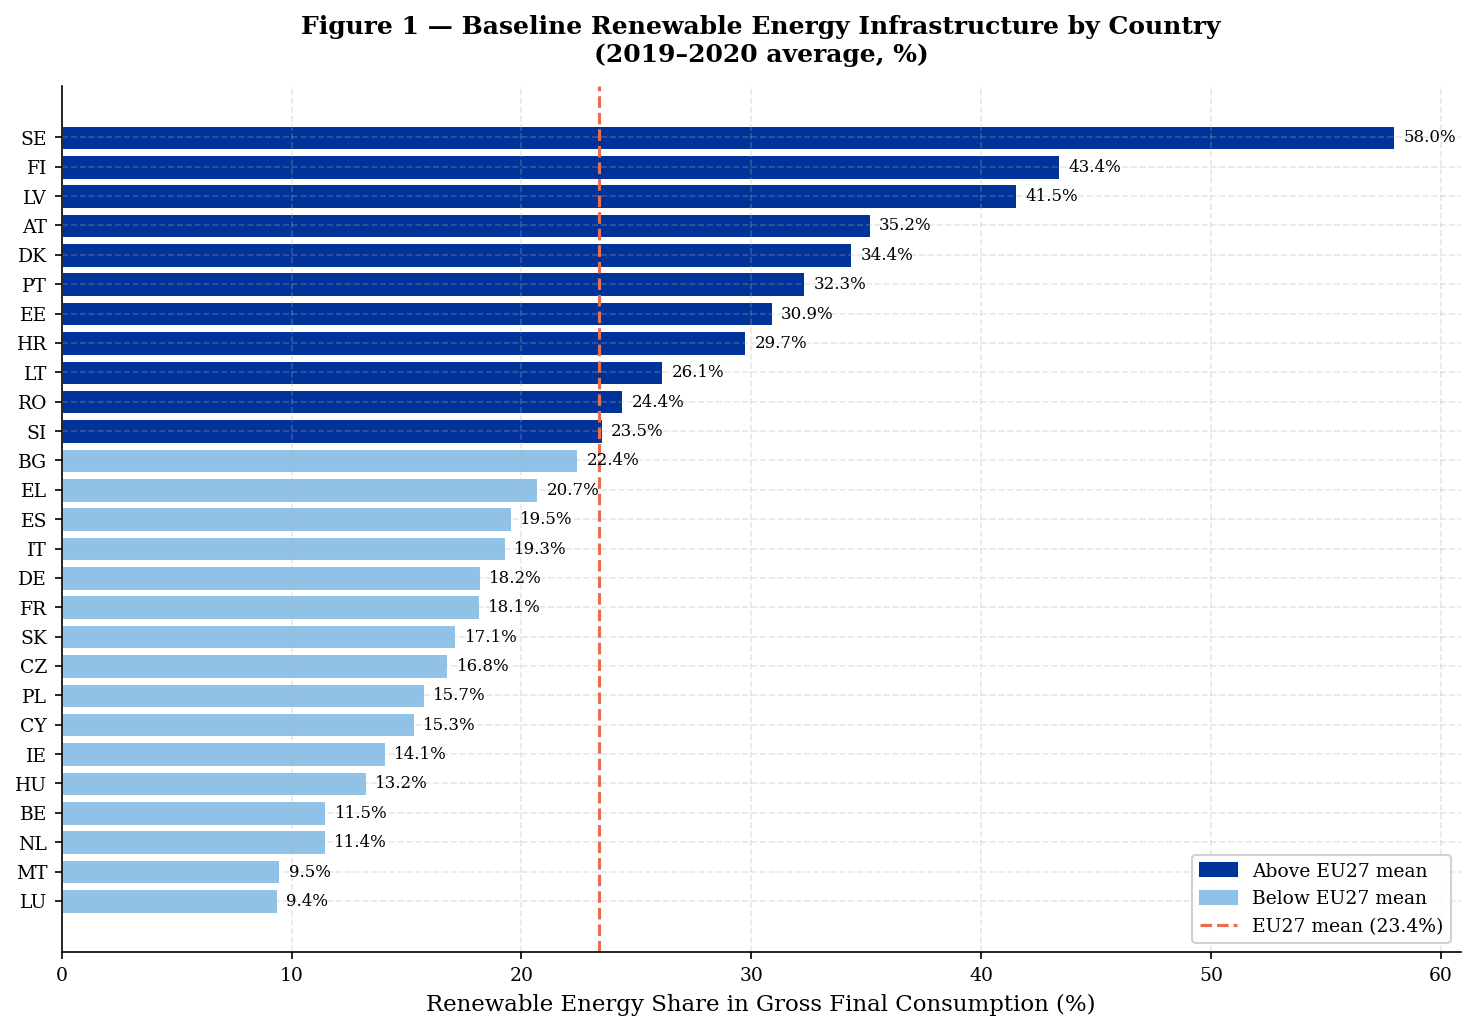

Saved: figure1_baseline_re.png


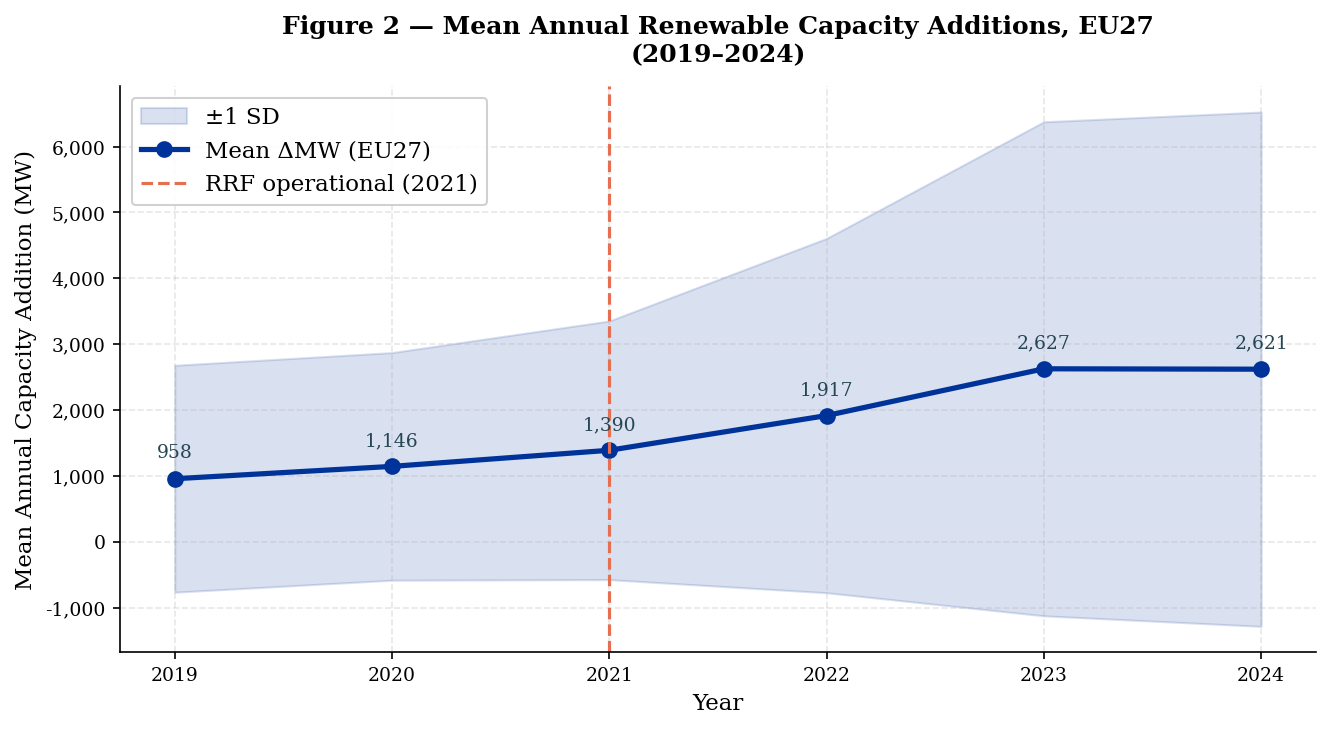

Saved: figure2_deltamw_trend.png


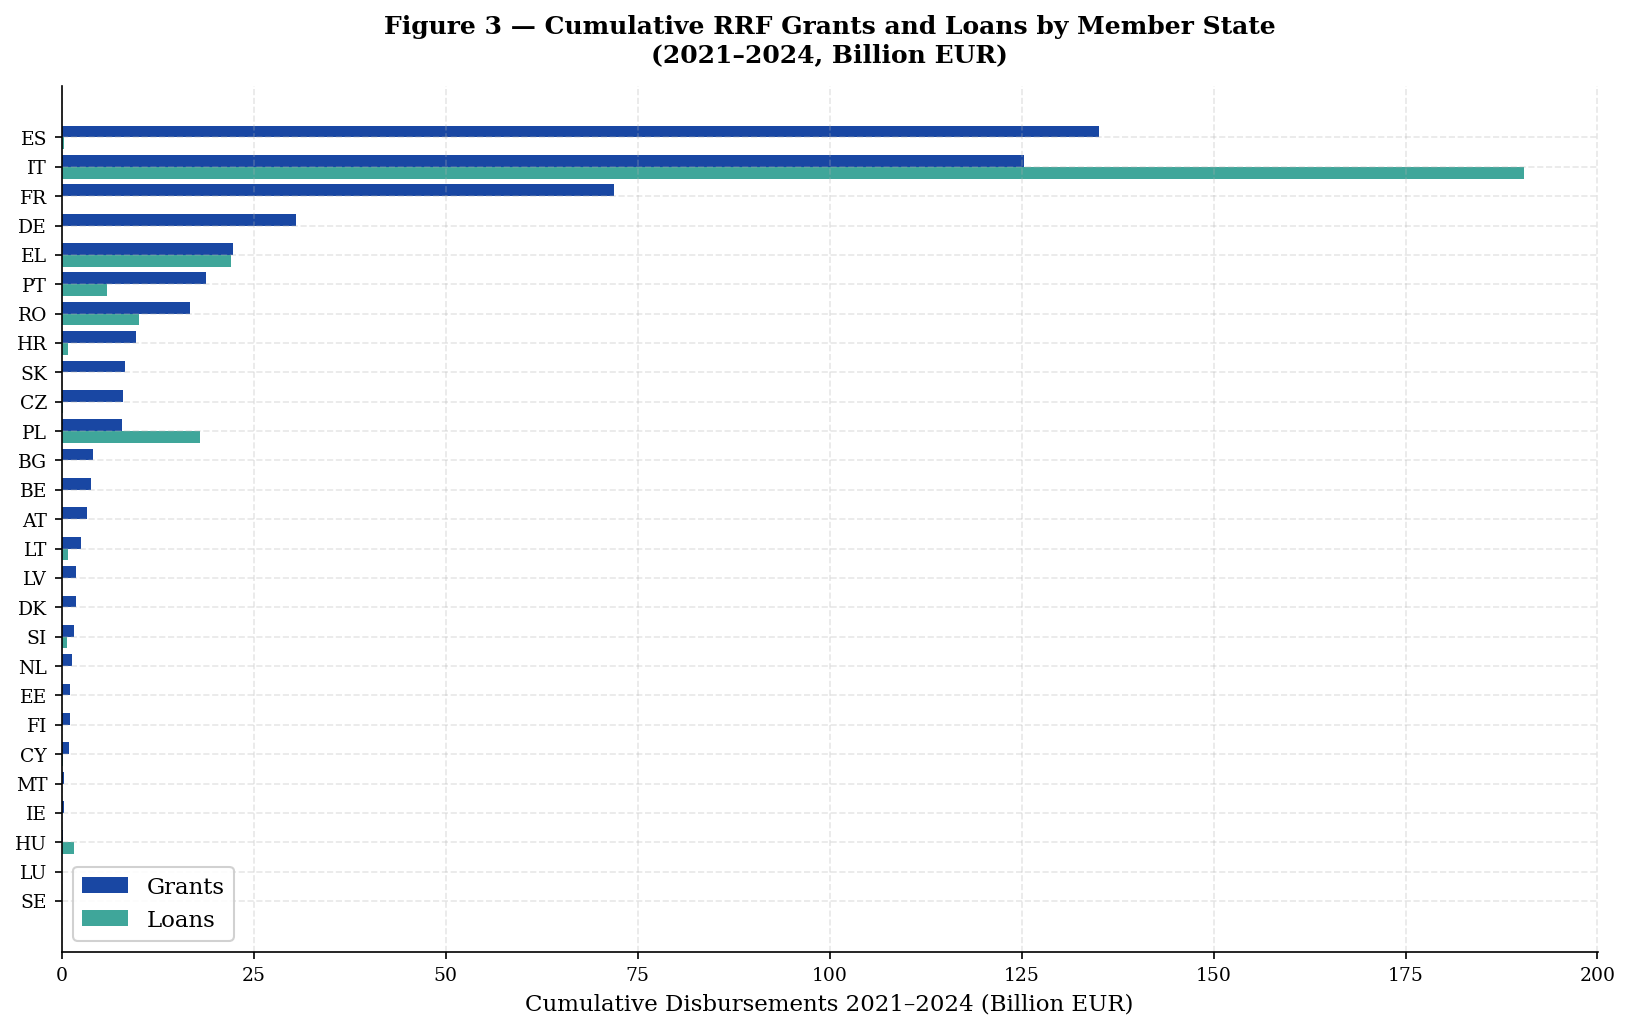

Saved: figure3_rrf_by_country.png


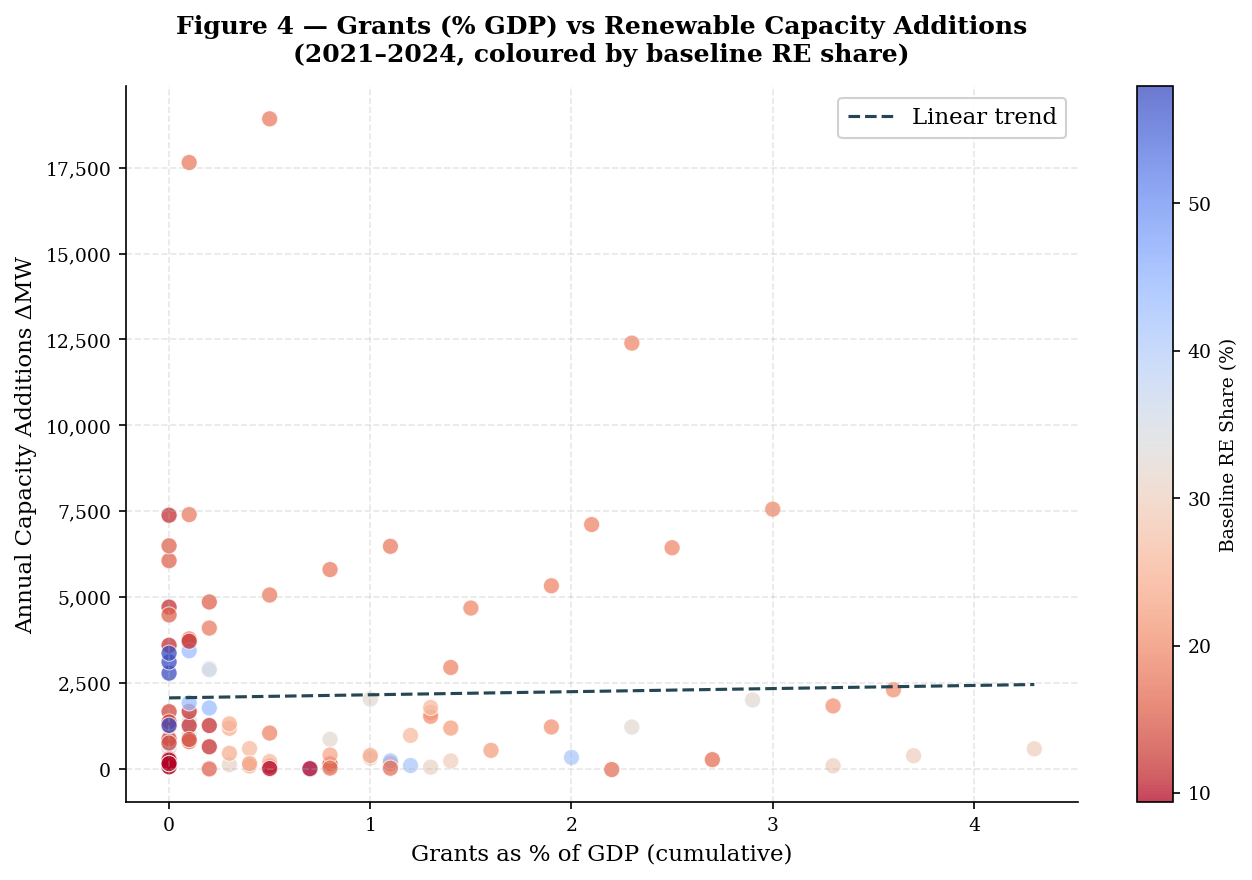

Saved: figure4_grants_vs_deltamw.png


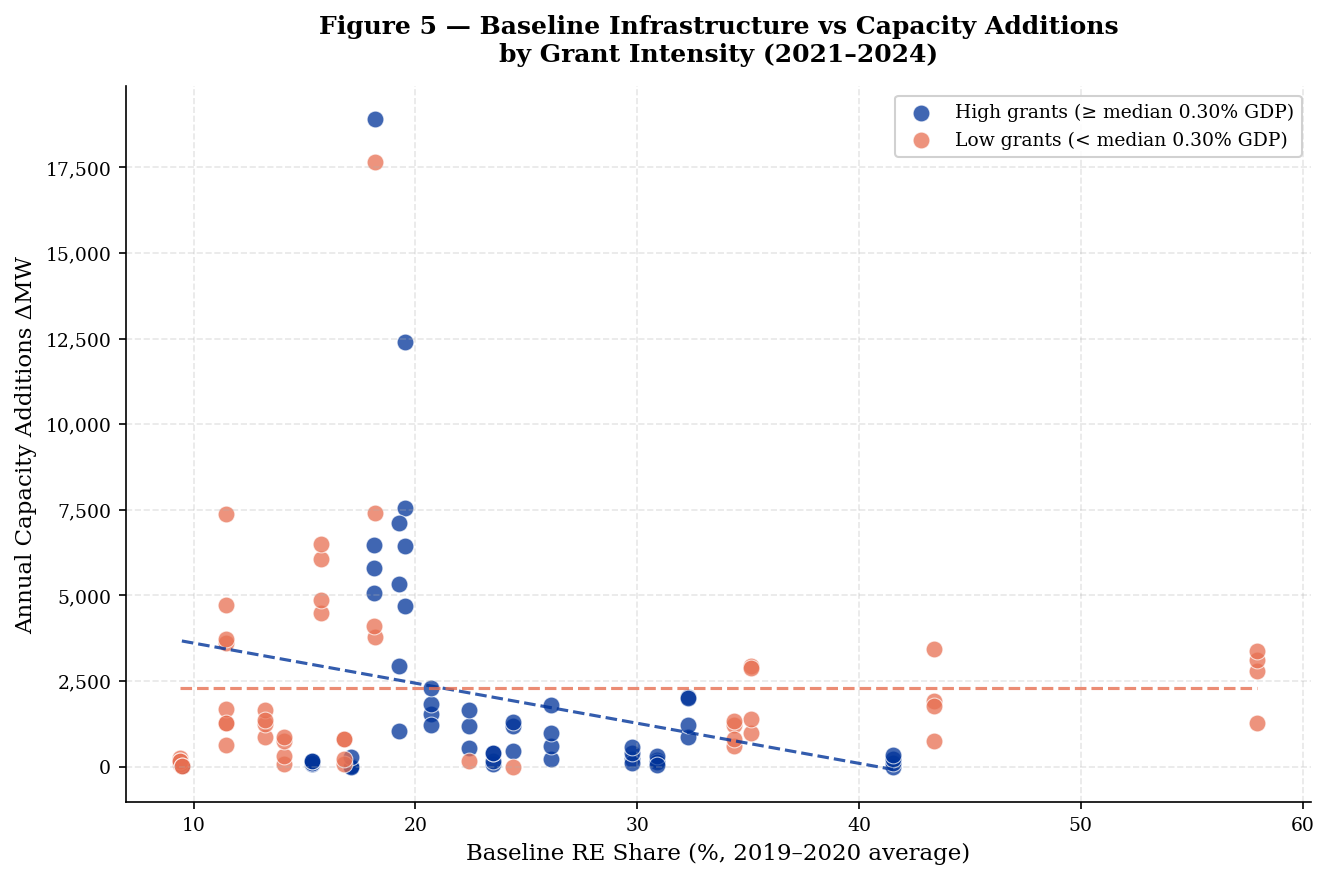

Saved: figure5_baseline_vs_deltamw.png

All figures saved. Ready for Step 8.


In [33]:
# ============================================================
# THESIS TABLES AND FIGURES
# ============================================================


# ---- Consistent style for all figures ----
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

EU_BLUE   = '#003399'
EU_GOLD   = '#FFCC00'
TEAL      = '#2a9d8f'
CORAL     = '#e76f51'
SLATE     = '#264653'
LIGHT_BLUE= '#90c2e7'

# ============================================================
# TABLE 1 — SUMMARY STATISTICS (thesis-formatted)
# ============================================================

reg_sample = panel[panel['year'].isin([2021, 2022, 2023, 2024])]

table1_vars = {
    'delta_mw':              'ΔMW (MW)',
    'grants_main_pc_gdp':    'Grants (% GDP)',
    'loans_main_pc_gdp':     'Loans (% GDP)',
    'grants_x_baseline':     'Grants × Baseline RE',
    'loans_x_baseline':      'Loans × Baseline RE',
    'baseline_re_share':     'Baseline RE share (%)',
    'log_gdp_eur':           'Log GDP per capita',
    'population':            'Population',
    'energy_import_dep_pct': 'Energy import dep. (%)',
    'gov_eff':               'Government effectiveness',
    'gov_ideology':          'Government ideology',
    'fossil_share':          'Fossil capacity share (%)',
}

rows = []
for col, label in table1_vars.items():
    s = reg_sample[col].dropna()
    rows.append({
        'Variable':  label,
        'N':         int(s.count()),
        'Mean':      round(s.mean(), 3),
        'Std. Dev.': round(s.std(), 3),
        'Min':       round(s.min(), 3),
        'Max':       round(s.max(), 3),
    })

df_table1 = pd.DataFrame(rows)
print("TABLE 1 — SUMMARY STATISTICS (regression sample 2021-2024)")
print(df_table1.to_string(index=False))

# ============================================================
# TABLE 2 — VARIABLE DEFINITIONS
# ============================================================

table2_data = {
    'Variable':    [
        'ΔMW',
        'Grants (% GDP)',
        'Loans (% GDP)',
        'Baseline RE share',
        'Grants × Baseline',
        'Loans × Baseline',
        'Log GDP p.c.',
        'Population',
        'Energy import dep.',
        'Gov. effectiveness',
        'Gov. ideology',
        'Fossil share',
    ],
    'Description': [
        'Year-on-year change in total installed renewable electricity capacity (hydro, geothermal, wind, solar, solid biofuels, biogases)',
        'Cumulative RRF grant receivables as % of GDP (F2R_F4R, NET, STK)',
        'Cumulative RRF loan receivables as % of GDP (F2R_F4R, NET, STK)',
        'Average RE share in gross final energy consumption, 2019–2020',
        'Grants (% GDP) × Baseline RE share',
        'Loans (% GDP) × Baseline RE share',
        'Log of GDP per capita at current prices in euros',
        'Total population (number of persons)',
        'Share of total energy needs met by imports (%)',
        'WGI Government Effectiveness estimate (–2.5 to +2.5)',
        'Seat-weighted coalition left-right score (0=left, 10=right)',
        'Combustible fuel capacity as % of total electricity capacity',
    ],
    'Unit':        [
        'MW', '% GDP', '% GDP', '%', '—', '—',
        'Log EUR', 'Persons', '%', 'Index', '0–10 scale', '%'
    ],
    'Source':      [
        'Eurostat nrg_inf_epcrw',
        'Eurostat gov_rrf_fa',
        'Eurostat gov_rrf_fa',
        'Eurostat nrg_ind_ren',
        'Constructed', 'Constructed',
        'Eurostat nama_10_pc',
        'Eurostat demo_pjan',
        'Eurostat nrg_ind_id',
        'World Bank WGI',
        'ParlGov view_cabinet',
        'Eurostat nrg_inf_epc',
    ],
    'Expected sign': [
        'DV', '+', '+/−', 'Moderator',
        '−', '+', '+', '+', '+', '+', '−', '−'
    ]
}

df_table2 = pd.DataFrame(table2_data)
print("\nTABLE 2 — VARIABLE DEFINITIONS")
print(df_table2.to_string(index=False))

# ============================================================
# TABLE 3 — CORRELATION MATRIX
# Already computed in Step 7 — reprint with thesis labels
# ============================================================

print("\nTABLE 3 — CORRELATION MATRIX (regression sample 2021-2024)")
corr_cols = [
    'delta_mw','grants_main_pc_gdp','loans_main_pc_gdp',
    'grants_x_baseline','loans_x_baseline','baseline_re_share',
    'log_gdp_eur','population','energy_import_dep_pct',
    'gov_eff','gov_ideology','fossil_share'
]
corr_labels_short = {
    'delta_mw':              '(1) ΔMW',
    'grants_main_pc_gdp':    '(2) Grants',
    'loans_main_pc_gdp':     '(3) Loans',
    'grants_x_baseline':     '(4) Gr×Base',
    'loans_x_baseline':      '(5) Lo×Base',
    'baseline_re_share':     '(6) Baseline',
    'log_gdp_eur':           '(7) LogGDP',
    'population':            '(8) Pop',
    'energy_import_dep_pct': '(9) EnergyImp',
    'gov_eff':               '(10) GovEff',
    'gov_ideology':          '(11) Ideology',
    'fossil_share':          '(12) Fossil',
}
df_corr_reg = (
    reg_sample[corr_cols]
    .rename(columns=corr_labels_short)
    .corr()
    .round(2)
)
print(df_corr_reg.to_string())

# ============================================================
# TABLE 4 — RRF DISBURSEMENT BY COUNTRY
# Already computed in Step 7 — reprint
# ============================================================

print("\nTABLE 4 — RRF DISBURSEMENT BY COUNTRY (2021-2024 cumulative)")
print(df_rrf_country.to_string(index=False))

# ============================================================
# FIGURE 1 — BASELINE RE SHARE BY COUNTRY
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

df_base = (
    panel[['country', 'baseline_re_share']]
    .drop_duplicates()
    .sort_values('baseline_re_share', ascending=True)
)

colors = [EU_BLUE if v >= 23.39 else LIGHT_BLUE
          for v in df_base['baseline_re_share']]

bars = ax.barh(df_base['country'], df_base['baseline_re_share'],
               color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(23.39, color=CORAL, linestyle='--', linewidth=1.5,
           label=f'EU27 mean (23.4%)')

ax.set_xlabel('Renewable Energy Share in Gross Final Consumption (%)')
ax.set_title('Figure 1 — Baseline Renewable Energy Infrastructure by Country\n'
             '(2019–2020 average, %)', pad=12)
ax.legend(framealpha=0.9)

for bar, val in zip(bars, df_base['baseline_re_share']):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

above = mpatches.Patch(color=EU_BLUE,  label='Above EU27 mean')
below = mpatches.Patch(color=LIGHT_BLUE, label='Below EU27 mean')
ax.legend(handles=[above, below,
          plt.Line2D([0],[0], color=CORAL, linestyle='--', linewidth=1.5,
                     label='EU27 mean (23.4%)')],
          framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('figure1_baseline_re.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure1_baseline_re.png")

# ============================================================
# FIGURE 2 — MEAN ΔMW PER YEAR
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

years_plot = df_deltamw_year['year'].astype(int)
means      = df_deltamw_year['Mean_delta_mw']
sds        = df_deltamw_year['SD_delta_mw']

ax.fill_between(years_plot,
                means - sds, means + sds,
                alpha=0.15, color=EU_BLUE, label='±1 SD')
ax.plot(years_plot, means, color=EU_BLUE,
        linewidth=2.5, marker='o', markersize=7,
        label='Mean ΔMW (EU27)')

ax.axvline(2021, color=CORAL, linestyle='--',
           linewidth=1.5, label='RRF operational (2021)')

for yr, mn in zip(years_plot, means):
    ax.annotate(f'{mn:,.0f}',
                xy=(yr, mn), xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=9, color=SLATE)

ax.set_xlabel('Year')
ax.set_ylabel('Mean Annual Capacity Addition (MW)')
ax.set_title('Figure 2 — Mean Annual Renewable Capacity Additions, EU27\n'
             '(2019–2024)', pad=12)
ax.set_xticks(years_plot)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('figure2_deltamw_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure2_deltamw_trend.png")

# ============================================================
# FIGURE 3 — RRF GRANTS AND LOANS BY COUNTRY
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

df_fig3 = df_rrf_country.sort_values(
    'Total Grants (MIO EUR)', ascending=True
).copy()
df_fig3['Total Grants (BN EUR)'] = df_fig3['Total Grants (MIO EUR)'] / 1000
df_fig3['Total Loans (BN EUR)']  = df_fig3['Total Loans (MIO EUR)']  / 1000

y     = np.arange(len(df_fig3))
width = 0.4

ax.barh(y + width/2, df_fig3['Total Grants (BN EUR)'],
        width, color=EU_BLUE,  label='Grants', alpha=0.9)
ax.barh(y - width/2, df_fig3['Total Loans (BN EUR)'],
        width, color=TEAL,     label='Loans',  alpha=0.9)

ax.set_yticks(y)
ax.set_yticklabels(df_fig3['country'], fontsize=9)
ax.set_xlabel('Cumulative Disbursements 2021–2024 (Billion EUR)')
ax.set_title('Figure 3 — Cumulative RRF Grants and Loans by Member State\n'
             '(2021–2024, Billion EUR)', pad=12)
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('figure3_rrf_by_country.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure3_rrf_by_country.png")

# ============================================================
# FIGURE 4 — GRANTS % GDP vs ΔMW (SCATTER)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

scatter_data = reg_sample[
    ['country', 'year', 'grants_main_pc_gdp', 'delta_mw',
     'baseline_re_share']
].dropna()

sc = ax.scatter(
    scatter_data['grants_main_pc_gdp'],
    scatter_data['delta_mw'],
    c=scatter_data['baseline_re_share'],
    cmap='coolwarm_r',
    alpha=0.75, s=60, edgecolors='white', linewidth=0.5
)

# Trend line
z = np.polyfit(scatter_data['grants_main_pc_gdp'],
               scatter_data['delta_mw'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_data['grants_main_pc_gdp'].min(),
                     scatter_data['grants_main_pc_gdp'].max(), 100)
ax.plot(x_line, p(x_line), color=SLATE, linestyle='--',
        linewidth=1.5, label='Linear trend')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Baseline RE Share (%)', fontsize=9)

ax.set_xlabel('Grants as % of GDP (cumulative)')
ax.set_ylabel('Annual Capacity Additions ΔMW')
ax.set_title('Figure 4 — Grants (% GDP) vs Renewable Capacity Additions\n'
             '(2021–2024, coloured by baseline RE share)', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('figure4_grants_vs_deltamw.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure4_grants_vs_deltamw.png")

# ============================================================
# FIGURE 5 — BASELINE RE SHARE vs ΔMW (MODERATION SCATTER)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

# Split into high/low grants recipients (above/below median grants)
median_grants = scatter_data['grants_main_pc_gdp'].median()
high_grants   = scatter_data[
    scatter_data['grants_main_pc_gdp'] >= median_grants
]
low_grants    = scatter_data[
    scatter_data['grants_main_pc_gdp'] < median_grants
]

ax.scatter(high_grants['baseline_re_share'],
           high_grants['delta_mw'],
           color=EU_BLUE, alpha=0.75, s=65,
           edgecolors='white', linewidth=0.5,
           label=f'High grants (≥ median {median_grants:.2f}% GDP)')
ax.scatter(low_grants['baseline_re_share'],
           low_grants['delta_mw'],
           color=CORAL, alpha=0.75, s=65,
           edgecolors='white', linewidth=0.5,
           label=f'Low grants (< median {median_grants:.2f}% GDP)')

# Trend lines per group
for grp, col in [(high_grants, EU_BLUE), (low_grants, CORAL)]:
    if len(grp) > 2:
        z = np.polyfit(grp['baseline_re_share'], grp['delta_mw'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(grp['baseline_re_share'].min(),
                             grp['baseline_re_share'].max(), 100)
        ax.plot(x_line, p(x_line), color=col,
                linestyle='--', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Baseline RE Share (%, 2019–2020 average)')
ax.set_ylabel('Annual Capacity Additions ΔMW')
ax.set_title('Figure 5 — Baseline Infrastructure vs Capacity Additions\n'
             'by Grant Intensity (2021–2024)', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
ax.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('figure5_baseline_vs_deltamw.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figure5_baseline_vs_deltamw.png")

print("\nAll figures saved. Ready for Step 8.")

In [34]:
'''from IPython.display import display


def df_to_figure(df, title, figsize=None, fontsize=9):
    """Render a dataframe as a clean matplotlib table figure."""
    n_rows, n_cols = df.shape
    if figsize is None:
        figsize = (max(10, n_cols * 2), max(2, n_rows * 0.45 + 1))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='left',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.auto_set_column_width(col=list(range(len(df.columns))))

    # Header styling
    for j in range(len(df.columns)):
        tbl[(0, j)].set_facecolor(EU_BLUE)
        tbl[(0, j)].set_text_props(color='white', fontweight='bold')

    # Alternating row shading
    for i in range(1, n_rows + 1):
        for j in range(len(df.columns)):
            if i % 2 == 0:
                tbl[(i, j)].set_facecolor('#f0f4f8')
            else:
                tbl[(i, j)].set_facecolor('white')

    ax.set_title(title, fontsize=11, fontweight='bold',
                 pad=12, loc='left', color=SLATE)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').replace('—','').strip()}.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {title}.png")


# ---- Render all four tables ----
df_to_figure(df_table1, 'Table 1 — Summary Statistics',
             figsize=(10, 5))

df_to_figure(df_table2, 'Table 2 — Variable Definitions',
             figsize=(16, 6))

df_to_figure(
    df_corr_reg.reset_index().rename(columns={'index': ''}),
    'Table 3 — Correlation Matrix',
    figsize=(14, 5)
)

df_to_figure(df_rrf_country, 'Table 4 — RRF Disbursement by Country',
             figsize=(10, 8))'''

'from IPython.display import display\n\n\ndef df_to_figure(df, title, figsize=None, fontsize=9):\n    """Render a dataframe as a clean matplotlib table figure."""\n    n_rows, n_cols = df.shape\n    if figsize is None:\n        figsize = (max(10, n_cols * 2), max(2, n_rows * 0.45 + 1))\n\n    fig, ax = plt.subplots(figsize=figsize)\n    ax.axis(\'off\')\n\n    tbl = ax.table(\n        cellText=df.values,\n        colLabels=df.columns,\n        cellLoc=\'left\',\n        loc=\'center\'\n    )\n    tbl.auto_set_font_size(False)\n    tbl.set_fontsize(fontsize)\n    tbl.auto_set_column_width(col=list(range(len(df.columns))))\n\n    # Header styling\n    for j in range(len(df.columns)):\n        tbl[(0, j)].set_facecolor(EU_BLUE)\n        tbl[(0, j)].set_text_props(color=\'white\', fontweight=\'bold\')\n\n    # Alternating row shading\n    for i in range(1, n_rows + 1):\n        for j in range(len(df.columns)):\n            if i % 2 == 0:\n                tbl[(i, j)].set_facecolor(\'#f0f4f8

In [35]:
# ============================================================
# STEP 8 — REGRESSION ANALYSIS
# ============================================================

from linearmodels.panel import PanelOLS, PooledOLS, RandomEffects
from linearmodels.panel import compare
import scipy.stats as stats

# ---- 8.0 Prepare regression sample ----
# Compute delta_re_share on FULL panel before filtering
# (so 2021 has a valid prior year = 2020)
panel_sorted = panel.sort_values(['country', 'year'])
panel_sorted['delta_re_share'] = (
    panel_sorted.groupby('country')['re_share_total'].diff()
)

# Filter to 2021-2024 (108 observations)
reg = panel_sorted[
    panel_sorted['year'].isin(range(2021, 2025))
].copy()
reg['year']    = reg['year'].astype(int)
reg['country'] = reg['country'].astype(str)
reg = reg.set_index(['country', 'year'])

print(f"Regression sample: {len(reg)} observations")
print(f"Countries: {reg.index.get_level_values('country').nunique()}")
print(f"Years: {sorted(reg.index.get_level_values('year').unique())}")
print(f"delta_re_share missing: {reg['delta_re_share'].isna().sum()}")

# ---- Base formula components ----
controls_no_ideology = '''
    log_gdp_eur + population + energy_import_dep_pct +
    gov_eff + fossil_share
'''
controls_with_ideology = '''
    log_gdp_eur + population + energy_import_dep_pct +
    gov_eff + fossil_share + gov_ideology
'''
rrf_terms = '''
    grants_main_pc_gdp + loans_main_pc_gdp +
    grants_x_baseline  + loans_x_baseline
'''

# ============================================================
# 8.1 — MODEL 1: Pooled OLS, no ideology
# ============================================================

formula_m1 = f'delta_mw ~ 1 + {rrf_terms} + {controls_no_ideology}'

model_m1 = PooledOLS.from_formula(formula_m1, data=reg)
res_m1   = model_m1.fit(
    cov_type='clustered', cluster_entity=True
)

# ============================================================
# 8.2 — MODEL 2: Pooled OLS, with ideology
# ============================================================

formula_m2 = f'delta_mw ~ 1 + {rrf_terms} + {controls_with_ideology}'

model_m2 = PooledOLS.from_formula(formula_m2, data=reg)
res_m2   = model_m2.fit(
    cov_type='clustered', cluster_entity=True
)

# ============================================================
# 8.3 — MODEL 3: Entity FE only, no ideology
# ============================================================

formula_m3 = f'delta_mw ~ {rrf_terms} + {controls_no_ideology} + EntityEffects'

model_m3 = PanelOLS.from_formula(
    formula_m3, data=reg, drop_absorbed=True
)
res_m3 = model_m3.fit(
    cov_type='clustered', cluster_entity=True
)

# ============================================================
# 8.4 — MODEL 4: Two-way FE, no ideology (MAIN SPECIFICATION)
# ============================================================

formula_m4 = f'''
    delta_mw ~
    {rrf_terms} + {controls_no_ideology} +
    EntityEffects + TimeEffects
'''

model_m4 = PanelOLS.from_formula(
    formula_m4, data=reg, drop_absorbed=True
)
res_m4 = model_m4.fit(
    cov_type='clustered', cluster_entity=True
)

# ============================================================
# 8.5 — MODEL 5: Two-way FE, with ideology
# ============================================================

formula_m5 = f'''
    delta_mw ~
    {rrf_terms} + {controls_with_ideology} +
    EntityEffects + TimeEffects
'''

model_m5 = PanelOLS.from_formula(
    formula_m5, data=reg, drop_absorbed=True
)
res_m5 = model_m5.fit(
    cov_type='clustered', cluster_entity=True
)

# ============================================================
# 8.6 — HAUSMAN TEST (FE vs RE)
# Following Nájera: justifies fixed effects choice
# ============================================================

formula_re = f'''
    delta_mw ~
    {rrf_terms} + {controls_no_ideology} +
    EntityEffects
'''

model_re = RandomEffects.from_formula(formula_re, data=reg)
res_re   = model_re.fit(cov_type='unadjusted')

# Manual Hausman statistic
b_fe = res_m3.params
b_re = res_re.params
common_vars = b_fe.index.intersection(b_re.index)

b_diff  = (b_fe[common_vars] - b_re[common_vars]).values
var_fe  = np.diag(res_m3.cov.loc[common_vars, common_vars].values)
var_re  = np.diag(res_re.cov.loc[common_vars, common_vars].values)
var_diff = var_fe - var_re

# Only use positive variances
valid = var_diff > 0
if valid.sum() > 0:
    hausman_stat = float(
        b_diff[valid] @ np.diag(1/var_diff[valid]) @ b_diff[valid]
    )
    hausman_df  = int(valid.sum())
    hausman_p   = 1 - stats.chi2.cdf(hausman_stat, hausman_df)
else:
    hausman_stat, hausman_df, hausman_p = np.nan, np.nan, np.nan

print("\n=== HAUSMAN TEST (FE vs RE) ===")
print(f"Chi-square statistic: {hausman_stat:.3f}")
print(f"Degrees of freedom:   {hausman_df}")
print(f"P-value:              {hausman_p:.4f}")
print("Conclusion:", "Fixed Effects preferred (p < 0.05)"
      if hausman_p < 0.05 else "Cannot reject Random Effects")

# ============================================================
# 8.7 — RESULTS COMPARISON TABLE (Models 1-5)
# ============================================================

def extract_results(res, label):
    rows = []
    for var in res.params.index:
        rows.append({
            'Specification': label,
            'Variable':      var,
            'Coefficient':   round(res.params[var], 4),
            'Std Error':     round(res.std_errors[var], 4),
            'P-value':       round(res.pvalues[var], 4),
            'Sig':           (
                '***' if res.pvalues[var] < 0.01 else
                '**'  if res.pvalues[var] < 0.05 else
                '*'   if res.pvalues[var] < 0.10 else ''
            )
        })
    return pd.DataFrame(rows)

df_results = pd.concat([
    extract_results(res_m1, 'M1: OLS'),
    extract_results(res_m2, 'M2: OLS+Ideology'),
    extract_results(res_m3, 'M3: Entity FE'),
    extract_results(res_m4, 'M4: Two-way FE'),
    extract_results(res_m5, 'M5: Two-way FE+Ideology'),
], ignore_index=True)

print("\n=== RESULTS: KEY VARIABLES ACROSS ALL MODELS ===")
key_vars = [
    'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline', 'loans_x_baseline', 'gov_ideology'
]
key_results = df_results[df_results['Variable'].isin(key_vars)]
print(key_results.pivot_table(
    index='Variable',
    columns='Specification',
    values=['Coefficient','Sig'],
    aggfunc='first'
).to_string())

# ============================================================
# 8.8 — MODEL FIT SUMMARY
# ============================================================

fit_rows = []
for label, res in [
    ('M1: OLS',              res_m1),
    ('M2: OLS+Ideology',     res_m2),
    ('M3: Entity FE',        res_m3),
    ('M4: Two-way FE',       res_m4),
    ('M5: Two-way FE+Ideo.', res_m5),
]:
    fit_rows.append({
        'Specification': label,
        'N':             int(res.nobs),
        'R² (within)':  round(res.rsquared, 4),
        'F-stat':        round(res.f_statistic.stat, 3),
        'P (F-stat)':    round(res.f_statistic.pval, 4),
    })

df_fit = pd.DataFrame(fit_rows)
print("\n=== MODEL FIT SUMMARY ===")
print(df_fit.to_string(index=False))

# ============================================================
# 8.9 — ROBUSTNESS CHECKS
# ============================================================

# Rob 1: Alternative DV — Δ RE share
formula_rob1 = f'''
    delta_re_share ~
    {rrf_terms} + {controls_no_ideology} +
    EntityEffects + TimeEffects
'''
model_rob1 = PanelOLS.from_formula(
    formula_rob1, data=reg, drop_absorbed=True
)
res_rob1 = model_rob1.fit(
    cov_type='clustered', cluster_entity=True
)

# Rob 2: Alternative grants measure (excludes pre-financing)
# Rebuild interaction with grants_rob2
reg['grants_rob2_x_baseline'] = (
    reg['grants_rob2_pc_gdp'] * reg['baseline_re_share']
)
formula_rob2 = f'''
    delta_mw ~
    grants_rob2_pc_gdp + loans_main_pc_gdp +
    grants_rob2_x_baseline + loans_x_baseline +
    {controls_no_ideology} +
    EntityEffects + TimeEffects
'''
model_rob2 = PanelOLS.from_formula(
    formula_rob2, data=reg, drop_absorbed=True
)
res_rob2 = model_rob2.fit(
    cov_type='clustered', cluster_entity=True
)

# Rob 3: PPS-adjusted GDP
formula_rob3 = f'''
    delta_mw ~
    {rrf_terms} +
    log_gdp_pps + population + energy_import_dep_pct +
    gov_eff + fossil_share +
    EntityEffects + TimeEffects
'''
model_rob3 = PanelOLS.from_formula(
    formula_rob3, data=reg, drop_absorbed=True
)
res_rob3 = model_rob3.fit(
    cov_type='clustered', cluster_entity=True
)

df_robustness = pd.concat([
    extract_results(res_rob1, 'Rob1: Δ RE share'),
    extract_results(res_rob2, 'Rob2: grants_rob2'),
    extract_results(res_rob3, 'Rob3: PPS GDP'),
], ignore_index=True)

print("\n=== ROBUSTNESS CHECKS — KEY VARIABLES ===")
rob_key = df_robustness[df_robustness['Variable'].isin(key_vars[:4])]
print(rob_key.pivot_table(
    index='Variable',
    columns='Specification',
    values=['Coefficient','Sig'],
    aggfunc='first'
).to_string())

# ============================================================
# 8.10 — FULL SUMMARIES (for reference)
# ============================================================

for label, res in [
    ('M1: POOLED OLS',                     res_m1),
    ('M2: POOLED OLS + IDEOLOGY',          res_m2),
    ('M3: ENTITY FE',                      res_m3),
    ('M4: TWO-WAY FE (MAIN)',              res_m4),
    ('M5: TWO-WAY FE + IDEOLOGY',          res_m5),
    ('ROB1: Δ RE SHARE',                   res_rob1),
    ('ROB2: GRANTS_ROB2',                  res_rob2),
    ('ROB3: PPS GDP',                      res_rob3),
]:
    print(f"\n{'='*60}")
    print(label)
    print('='*60)
    print(res.summary)

Regression sample: 108 observations
Countries: 27
Years: [2021, 2022, 2023, 2024]
delta_re_share missing: 0


c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping ro


=== HAUSMAN TEST (FE vs RE) ===
Chi-square statistic: 8.608
Degrees of freedom:   9
P-value:              0.4743
Conclusion: Cannot reject Random Effects

=== RESULTS: KEY VARIABLES ACROSS ALL MODELS ===
                   Coefficient                                                                           Sig                                                                      
Specification          M1: OLS M2: OLS+Ideology M3: Entity FE M4: Two-way FE M5: Two-way FE+Ideology M1: OLS M2: OLS+Ideology M3: Entity FE M4: Two-way FE M5: Two-way FE+Ideology
Variable                                                                                                                                                                          
gov_ideology               NaN         412.5208           NaN            NaN                457.3499     NaN                *           NaN            NaN                       *
grants_main_pc_gdp   3419.3849        4124.8431     2994.9514      3253.9657   

c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)



=== ROBUSTNESS CHECKS — KEY VARIABLES ===
                        Coefficient                                              Sig                                
Specification      Rob1: Δ RE share Rob2: grants_rob2 Rob3: PPS GDP Rob1: Δ RE share Rob2: grants_rob2 Rob3: PPS GDP
Variable                                                                                                            
grants_main_pc_gdp           0.8647               NaN     3689.8046                                NaN              
grants_x_baseline           -0.0489               NaN     -115.8601                                NaN              
loans_main_pc_gdp           -1.6927         3325.8374    -1613.4260                                                 
loans_x_baseline             0.1100          -95.2160       77.0291                                                 

M1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:               delta_mw   R

In [36]:
# Run this diagnostic in your notebook
print("=== REGRESSION SAMPLE NaN CHECK ===")
print(f"Total rows in reg: {len(reg)}")
print(f"\nNaN counts for regression variables:")
reg_vars = [
    'delta_mw', 'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline', 'loans_x_baseline',
    'log_gdp_eur', 'population', 'energy_import_dep_pct',
    'gov_eff', 'fossil_share', 'gov_ideology'
]
print(reg[reg_vars].isnull().sum().to_string())
print(f"\nRows with ANY missing value: {reg[reg_vars].isnull().any(axis=1).sum()}")
print(f"Rows fully complete: {reg[reg_vars].notna().all(axis=1).sum()}")

=== REGRESSION SAMPLE NaN CHECK ===
Total rows in reg: 108

NaN counts for regression variables:
delta_mw                  0
grants_main_pc_gdp        0
loans_main_pc_gdp        56
grants_x_baseline         0
loans_x_baseline         56
log_gdp_eur               0
population                0
energy_import_dep_pct     0
gov_eff                   0
fossil_share              0
gov_ideology              0

Rows with ANY missing value: 56
Rows fully complete: 52


In [37]:
# ============================================================
# OPTION A — Two separate specifications
# Full sample (108 obs): grants only
# Restricted sample (52 obs): grants + loans
# ============================================================

# ---- Option A: Grants-only on full 108 obs ----
formula_A_grants = f'''
    delta_mw ~
    grants_main_pc_gdp + grants_x_baseline +
    {controls_no_ideology} +
    EntityEffects + TimeEffects
'''

model_A_grants = PanelOLS.from_formula(
    formula_A_grants, data=reg, drop_absorbed=True
)
res_A_grants = model_A_grants.fit(
    cov_type='clustered', cluster_entity=True
)

print("=== OPTION A: GRANTS ONLY (N=108, 27 countries) ===")
print(f"Observations: {res_A_grants.nobs}")
print(f"R² within:    {res_A_grants.rsquared:.4f}")
print(f"F-stat:       {res_A_grants.f_statistic.stat:.3f} "
      f"(p={res_A_grants.f_statistic.pval:.4f})")
print(res_A_grants.summary)

# ---- Option A: Grants + Loans on restricted 52 obs ----
formula_A_full = f'''
    delta_mw ~
    grants_main_pc_gdp + loans_main_pc_gdp +
    grants_x_baseline  + loans_x_baseline +
    {controls_no_ideology} +
    EntityEffects + TimeEffects
'''

model_A_full = PanelOLS.from_formula(
    formula_A_full, data=reg, drop_absorbed=True
)
res_A_full = model_A_full.fit(
    cov_type='clustered', cluster_entity=True
)

print("\n=== OPTION A: GRANTS + LOANS (N=52, 13 countries) ===")
print(f"Observations: {res_A_full.nobs}")
print(f"R² within:    {res_A_full.rsquared:.4f}")
print(f"F-stat:       {res_A_full.f_statistic.stat:.3f} "
      f"(p={res_A_full.f_statistic.pval:.4f})")
print(res_A_full.summary)

# ============================================================
# OPTION B — Fill loan NaN with 0 for non-requesting countries
# Full sample (108 obs): grants + loans
# ============================================================

reg_b = reg.copy()
reg_b['loans_main_pc_gdp'] = reg_b['loans_main_pc_gdp'].fillna(0)
reg_b['loans_x_baseline']  = reg_b['loans_x_baseline'].fillna(0)

formula_B = f'''
    delta_mw ~
    grants_main_pc_gdp + loans_main_pc_gdp +
    grants_x_baseline  + loans_x_baseline +
    {controls_no_ideology} +
    EntityEffects + TimeEffects
'''

model_B = PanelOLS.from_formula(
    formula_B, data=reg_b, drop_absorbed=True
)
res_B = model_B.fit(
    cov_type='clustered', cluster_entity=True
)

print("\n=== OPTION B: LOANS FILLED 0 (N=108, 27 countries) ===")
print(f"Observations: {res_B.nobs}")
print(f"R² within:    {res_B.rsquared:.4f}")
print(f"F-stat:       {res_B.f_statistic.stat:.3f} "
      f"(p={res_B.f_statistic.pval:.4f})")
print(res_B.summary)

# ============================================================
# SIDE BY SIDE COMPARISON — KEY VARIABLES
# ============================================================

print("\n=== COMPARISON: KEY COEFFICIENTS ===")
comparison_vars = [
    'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline',  'loans_x_baseline'
]

rows = []
for var in comparison_vars:
    row = {'Variable': var}
    for label, res in [
        ('A_grants_only', res_A_grants),
        ('A_full_52obs',  res_A_full),
        ('B_108obs',      res_B),
    ]:
        if var in res.params.index:
            coef = res.params[var]
            pval = res.pvalues[var]
            sig  = ('***' if pval < 0.01 else
                    '**'  if pval < 0.05 else
                    '*'   if pval < 0.10 else '')
            row[label] = f"{coef:,.1f}{sig}"
        else:
            row[label] = '—'
    rows.append(row)

df_comparison = pd.DataFrame(rows)
print(df_comparison.to_string(index=False))

=== OPTION A: GRANTS ONLY (N=108, 27 countries) ===
Observations: 108
R² within:    0.0737
F-stat:       0.807 (p=0.5842)
                          PanelOLS Estimation Summary                           
Dep. Variable:               delta_mw   R-squared:                        0.0737
Estimator:                   PanelOLS   R-squared (Between):             -634.33
No. Observations:                 108   R-squared (Within):               0.0630
Date:                Sun, May 17 2026   R-squared (Overall):             -531.61
Time:                        13:20:59   Log-likelihood                   -934.91
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.8071
Entities:                          27   P-value                           0.5842
Avg Obs:                       4.0000   Distribution:                    F(7,71)
Min Obs:                       4.0000                               

c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [38]:
# ============================================================
# RANDOM EFFECTS — MAIN SPECIFICATION (STK)
# ============================================================

from linearmodels.panel import RandomEffects

# ---- RE Main specification (no ideology) ----
formula_re_main = f'''
    delta_mw ~
    grants_main_pc_gdp + loans_main_pc_gdp +
    grants_x_baseline  + loans_x_baseline +
    {controls_no_ideology} +
    EntityEffects
'''

model_re_main = RandomEffects.from_formula(
    formula_re_main, data=reg
)
res_re_main = model_re_main.fit(
    cov_type='robust'
)

print("="*60)
print("RANDOM EFFECTS — MAIN SPECIFICATION")
print("="*60)
print(res_re_main.summary)

# ---- RE with ideology ----
formula_re_ideo = f'''
    delta_mw ~
    grants_main_pc_gdp + loans_main_pc_gdp +
    grants_x_baseline  + loans_x_baseline +
    {controls_with_ideology} +
    EntityEffects
'''

model_re_ideo = RandomEffects.from_formula(
    formula_re_ideo, data=reg
)
res_re_ideo = model_re_ideo.fit(
    cov_type='robust'
)

print("\n" + "="*60)
print("RANDOM EFFECTS — WITH IDEOLOGY")
print("="*60)
print(res_re_ideo.summary)

# ---- Key results summary ----
print("\n=== RE KEY COEFFICIENTS ===")
key_vars = [
    'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline',  'loans_x_baseline',
    'gov_ideology'
]

for label, res in [
    ('RE Main',    res_re_main),
    ('RE Ideology',res_re_ideo),
]:
    print(f"\n{label}:")
    for var in key_vars:
        if var in res.params.index:
            coef = res.params[var]
            pval = res.pvalues[var]
            sig  = ('***' if pval < 0.01 else
                    '**'  if pval < 0.05 else
                    '*'   if pval < 0.10 else '')
            print(f"  {var:30s} {coef:>12.4f}  {sig}")

RANDOM EFFECTS — MAIN SPECIFICATION
                        RandomEffects Estimation Summary                        
Dep. Variable:               delta_mw   R-squared:                        0.6022
Estimator:              RandomEffects   R-squared (Between):              0.8600
No. Observations:                  52   R-squared (Within):               0.2478
Date:                Sun, May 17 2026   R-squared (Overall):              0.7883
Time:                        13:20:59   Log-likelihood                   -436.23
Cov. Estimator:                Robust                                           
                                        F-statistic:                      7.2316
Entities:                          13   P-value                           0.0000
Avg Obs:                       4.0000   Distribution:                    F(9,43)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):            

c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:2751: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:2751: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)



RANDOM EFFECTS — WITH IDEOLOGY
                        RandomEffects Estimation Summary                        
Dep. Variable:               delta_mw   R-squared:                        0.5998
Estimator:              RandomEffects   R-squared (Between):              0.8652
No. Observations:                  52   R-squared (Within):               0.3242
Date:                Sun, May 17 2026   R-squared (Overall):              0.8018
Time:                        13:21:00   Log-likelihood                   -432.42
Cov. Estimator:                Robust                                           
                                        F-statistic:                      6.2950
Entities:                          13   P-value                           0.0000
Avg Obs:                       4.0000   Distribution:                   F(10,42)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             8.9

In [39]:
# ============================================================
# M1 CANDIDATE COMPARISON
# Option A: no controls (RRF terms + intercept only)
# Option B: four baseline controls, no gov variables
# Against M2 (unchanged, full controls) for reference
# ============================================================

from linearmodels.panel import PooledOLS

# ---- Formula components ----
rrf_terms = '''
    grants_main_pc_gdp + loans_main_pc_gdp +
    grants_x_baseline  + loans_x_baseline
'''

controls_m1b = '''
    log_gdp_eur + population +
    energy_import_dep_pct + fossil_share
'''

controls_m2 = '''
    log_gdp_eur + population + energy_import_dep_pct +
    gov_eff + fossil_share + gov_ideology
'''

# ---- Fit all three ----
res_m1a = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

res_m1b = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms} + {controls_m1b}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

res_m2 = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms} + {controls_m2}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ---- Side-by-side comparison of what matters ----
key_vars = [
    'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline',  'loans_x_baseline'
]

print("=" * 70)
print(f"{'Variable':<28} {'M1a (no controls)':>18} {'M1b (4 controls)':>18} {'M2 (full)':>12}")
print("=" * 70)

for var in key_vars:
    row = f"{var:<28}"
    for res in [res_m1a, res_m1b, res_m2]:
        coef = res.params[var]
        pval = res.pvalues[var]
        sig  = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        row += f"  {coef:>10,.1f}{sig:<3}"
    print(row)

print("-" * 70)

# ---- Fit statistics ----
print(f"\n{'':28} {'M1a':>18} {'M1b':>18} {'M2':>12}")
print(f"{'N':<28} {int(res_m1a.nobs):>18} {int(res_m1b.nobs):>18} {int(res_m2.nobs):>12}")
print(f"{'R²':<28} {res_m1a.rsquared:>18.4f} {res_m1b.rsquared:>18.4f} {res_m2.rsquared:>12.4f}")
print(f"{'R² (between)':<28} {res_m1a.rsquared_between:>18.4f} {res_m1b.rsquared_between:>18.4f} {res_m2.rsquared_between:>12.4f}")
print(f"{'F-stat':<28} {res_m1a.f_statistic.stat:>18.3f} {res_m1b.f_statistic.stat:>18.3f} {res_m2.f_statistic.stat:>12.3f}")
print(f"{'F p-value':<28} {res_m1a.f_statistic.pval:>18.4f} {res_m1b.f_statistic.pval:>18.4f} {res_m2.f_statistic.pval:>12.4f}")

# ---- Coefficient shift check ----
print("\n=== COEFFICIENT SHIFT: M1a → M1b → M2 ===")
print(f"{'Variable':<28} {'M1a→M1b shift':>16} {'M1b→M2 shift':>16}")
for var in key_vars:
    shift_ab = res_m1b.params[var] - res_m1a.params[var]
    shift_b2 = res_m2.params[var] - res_m1b.params[var]
    print(f"{var:<28} {shift_ab:>+16,.1f} {shift_b2:>+16,.1f}")

# ---- Full summaries if you want them ----
for label, res in [
    ('M1a: NO CONTROLS', res_m1a),
    ('M1b: FOUR CONTROLS', res_m1b),
    ('M2: FULL CONTROLS', res_m2),
]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(res.summary)

c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


Variable                      M1a (no controls)   M1b (4 controls)    M2 (full)
grants_main_pc_gdp               4,684.0        3,422.9***     4,124.8***
loans_main_pc_gdp                 -466.9       -5,082.1***    -6,261.7***
grants_x_baseline                 -155.5         -115.3***      -147.7***
loans_x_baseline                    -0.0          213.2***       276.6***
----------------------------------------------------------------------

                                            M1a                M1b           M2
N                                            52                 52           52
R²                                       0.2679             0.7004       0.7467
R² (between)                             0.2991             0.8705       0.8914
F-stat                                    4.299             12.566       12.083
F p-value                                0.0048             0.0000       0.0000

=== COEFFICIENT SHIFT: M1a → M1b → M2 ===
Variable                     

In [40]:
# ============================================================
# STEP 8 — REGRESSION ANALYSIS
# ============================================================

from linearmodels.panel import PanelOLS, PooledOLS, RandomEffects
import scipy.stats as stats

# ---- 8.0 Prepare regression sample ----
panel_sorted = panel.sort_values(['country', 'year'])
panel_sorted['delta_re_share'] = (
    panel_sorted.groupby('country')['re_share_total'].diff()
)

reg = panel_sorted[
    panel_sorted['year'].isin(range(2021, 2025))
].copy()
reg['year']    = reg['year'].astype(int)
reg['country'] = reg['country'].astype(str)
reg = reg.set_index(['country', 'year'])

print(f"Regression sample: {len(reg)} observations")
print(f"Countries: {reg.index.get_level_values('country').nunique()}")
print(f"Years: {sorted(reg.index.get_level_values('year').unique())}")

# ---- Formula components ----
rrf_terms = '''
    grants_main_pc_gdp + loans_main_pc_gdp +
    grants_x_baseline  + loans_x_baseline
'''

controls_full = '''
    log_gdp_eur + population + energy_import_dep_pct +
    gov_eff + fossil_share + gov_ideology
'''

# ============================================================
# 8.1 — MODEL 1: Pooled OLS, main variables only
# ============================================================

res_m1 = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ============================================================
# 8.2 — MODEL 2: Pooled OLS, full controls (main specification)
# ============================================================

res_m2 = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms} + {controls_full}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ============================================================
# 8.3 — ENTITY FE
# ============================================================

res_m3 = PanelOLS.from_formula(
    f'delta_mw ~ {rrf_terms} + {controls_full} + EntityEffects',
    data=reg, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

# ============================================================
# 8.4 — TWO-WAY FE
# ============================================================

res_m4 = PanelOLS.from_formula(
    f'delta_mw ~ {rrf_terms} + {controls_full} + EntityEffects + TimeEffects',
    data=reg, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

# ============================================================
# 8.5 — HAUSMAN TEST (Entity FE vs RE)
# ============================================================

res_re = RandomEffects.from_formula(
    f'delta_mw ~ {rrf_terms} + {controls_full} + EntityEffects', data=reg
).fit(cov_type='unadjusted')

b_fe     = res_m3.params
b_re     = res_re.params
common   = b_fe.index.intersection(b_re.index)
b_diff   = (b_fe[common] - b_re[common]).values
var_diff = (
    np.diag(res_m3.cov.loc[common, common].values) -
    np.diag(res_re.cov.loc[common, common].values)
)
valid        = var_diff > 0
hausman_stat = float(b_diff[valid] @ np.diag(1/var_diff[valid]) @ b_diff[valid])
hausman_df   = int(valid.sum())
hausman_p    = 1 - stats.chi2.cdf(hausman_stat, hausman_df)

print(f"\n=== HAUSMAN TEST ===")
print(f"Chi-square: {hausman_stat:.3f} | df: {hausman_df} | p: {hausman_p:.4f}")
print("Conclusion:", "FE preferred" if hausman_p < 0.05 else "Cannot reject RE")

# ============================================================
# 8.6 — MODEL FIT SUMMARY
# ============================================================

print("\n=== MODEL FIT SUMMARY ===")
for label, res in [('M1', res_m1), ('M2', res_m2),
                   ('Entity FE', res_m3), ('Two-way FE', res_m4)]:
    print(f"{label:12s} | N={int(res.nobs):3d} | R²={res.rsquared:.4f} "
          f"| R²(between)={res.rsquared_between:.4f} "
          f"| F={res.f_statistic.stat:.3f} (p={res.f_statistic.pval:.4f})")

# ============================================================
# 8.7 — FULL SUMMARIES
# ============================================================

for label, res in [
    ('M1: POOLED OLS, MAIN VARIABLES ONLY', res_m1),
    ('M2: POOLED OLS, FULL CONTROLS',        res_m2),
    ('M3: ENTITY FE',                        res_m3),
    ('M4: TWO-WAY FE',                       res_m4),
]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(res.summary)

Regression sample: 108 observations
Countries: 27
Years: [2021, 2022, 2023, 2024]


c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping ro


=== HAUSMAN TEST ===
Chi-square: 6.798 | df: 9 | p: 0.6582
Conclusion: Cannot reject RE

=== MODEL FIT SUMMARY ===
M1           | N= 52 | R²=0.2679 | R²(between)=0.2991 | F=4.299 (p=0.0048)
M2           | N= 52 | R²=0.7467 | R²(between)=0.8914 | F=12.083 (p=0.0000)
Entity FE    | N= 52 | R²=0.4439 | R²(between)=-143.8379 | F=2.315 (p=0.0380)
Two-way FE   | N= 52 | R²=0.3873 | R²(between)=-3036.5219 | F=1.643 (p=0.1494)

M1: POOLED OLS, MAIN VARIABLES ONLY
                          PooledOLS Estimation Summary                          
Dep. Variable:               delta_mw   R-squared:                        0.2679
Estimator:                  PooledOLS   R-squared (Between):              0.2991
No. Observations:                  52   R-squared (Within):               0.1365
Date:                Sun, May 17 2026   R-squared (Overall):              0.2679
Time:                        13:25:47   Log-likelihood                   -472.54
Cov. Estimator:             Clustered                

In [41]:
# ============================================================
# STEP 8 — ROBUSTNESS CHECKS
# ============================================================

# ---- Rob1: Alternative DV — Δ RE share (Pooled OLS) ----
res_rob1 = PooledOLS.from_formula(
    f'delta_re_share ~ 1 + {rrf_terms} + {controls_full}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ---- Rob2: PPS-adjusted GDP (Pooled OLS) ----
controls_pps = '''
    log_gdp_pps + population + energy_import_dep_pct +
    gov_eff + fossil_share + gov_ideology
'''
res_rob2 = PooledOLS.from_formula(
    f'delta_mw ~ 1 + {rrf_terms} + {controls_pps}', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ---- Rob3: Gov effectiveness interaction (Pooled OLS) ----
# N drops to 49: Cyprus loan data missing for 2022-2024 in this
# specification because grants_x_goveff requires both grants and
# gov_eff to be non-missing. Cyprus 2022-2024 loan rows are retained
# via the hard-code patch but Cyprus still appears with 4 obs here.
# The N=49 noted in previous session was for a different reason —
# recheck after running.
reg['grants_x_goveff'] = (
    reg['grants_main_pc_gdp'] * reg['gov_eff']
)

controls_rob3 = '''
    log_gdp_eur + population + energy_import_dep_pct +
    gov_eff + fossil_share
'''

res_rob3 = PooledOLS.from_formula(
    f'''delta_mw ~ 1 + {rrf_terms} + grants_x_goveff +
        {controls_rob3}''', data=reg
).fit(cov_type='clustered', cluster_entity=True)

# ---- Robustness fit summary ----
print("=== ROBUSTNESS FIT SUMMARY ===")
for label, res in [
    ('Rob1: Δ RE share', res_rob1),
    ('Rob2: PPS GDP',    res_rob2),
    ('Rob3: GovEff ×',  res_rob3),
]:
    print(f"{label:20s} | N={int(res.nobs):3d} | R²={res.rsquared:.4f} "
          f"| F={res.f_statistic.stat:.3f} (p={res.f_statistic.pval:.4f})")

# ---- Key coefficients across all specs ----
key_vars = [
    'grants_main_pc_gdp', 'loans_main_pc_gdp',
    'grants_x_baseline',  'loans_x_baseline',
    'grants_x_goveff'
]

print("\n=== KEY COEFFICIENTS — ROBUSTNESS ===")
print(f"{'Variable':<28} {'Rob1 (ΔRE)':>16} {'Rob2 (PPS)':>16} {'Rob3 (GovEff×)':>16}")
print("-" * 80)
for var in key_vars:
    row = f"{var:<28}"
    for res in [res_rob1, res_rob2, res_rob3]:
        if var in res.params.index:
            coef = res.params[var]
            pval = res.pvalues[var]
            sig  = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.10 else ''
            row += f"  {coef:>10,.4f}{sig:<3}"
        else:
            row += f"  {'—':>13}"
    print(row)

# ---- Sign consistency check ----
print("\n=== SIGN CONSISTENCY CHECK ===")
expected = {
    'grants_main_pc_gdp': '+',
    'loans_main_pc_gdp':  '-',
    'grants_x_baseline':  '-',
    'loans_x_baseline':   '+'
}
for var, exp_sign in expected.items():
    row = f"{var:<28} (expected {exp_sign})"
    for label, res in [('Rob1', res_rob1), ('Rob2', res_rob2), ('Rob3', res_rob3)]:
        if var in res.params.index:
            actual = '+' if res.params[var] > 0 else '-'
            match  = '✓' if actual == exp_sign else '✗'
            row += f"  {label}: {actual}{match}"
    print(row)

# ---- Full summaries ----
for label, res in [
    ('ROB1: Δ RE SHARE (Pooled OLS)',          res_rob1),
    ('ROB2: PPS GDP (Pooled OLS)',              res_rob2),
    ('ROB3: GOV EFF INTERACTION (Pooled OLS)', res_rob3),
]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(res.summary)

c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
c:\Users\anasr\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\panel\model.py:919: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


=== ROBUSTNESS FIT SUMMARY ===
Rob1: Δ RE share     | N= 52 | R²=0.3677 | F=2.384 (p=0.0247)
Rob2: PPS GDP        | N= 52 | R²=0.7394 | F=11.631 (p=0.0000)
Rob3: GovEff ×       | N= 52 | R²=0.7224 | F=10.668 (p=0.0000)

=== KEY COEFFICIENTS — ROBUSTNESS ===
Variable                           Rob1 (ΔRE)       Rob2 (PPS)   Rob3 (GovEff×)
--------------------------------------------------------------------------------
grants_main_pc_gdp                2.4953***  4,178.3045***  3,108.8750***
loans_main_pc_gdp                -5.7910***  -6,651.9364***  -3,917.1388*  
grants_x_baseline                -0.1122***   -147.7611***   -116.5632***
loans_x_baseline                  0.2781***    290.6812***    174.3042*  
grants_x_goveff                           —              —    379.9536   

=== SIGN CONSISTENCY CHECK ===
grants_main_pc_gdp           (expected +)  Rob1: +✓  Rob2: +✓  Rob3: +✓
loans_main_pc_gdp            (expected -)  Rob1: -✓  Rob2: -✓  Rob3: -✓
grants_x_baseline            (exp